# 4.1 — Clinical Model Evaluation (Beyond RMSE)

Rigorous, clinically relevant evaluation of every trained **(dataset × model)** pair.  
Loads all pipelines from `./models/all_results_cache.joblib` — **no re-training required**.

## Why this notebook exists

Standard regression metrics (RMSE, R², MAE) are necessary but not sufficient for NHS clinical work.  
This notebook implements five evaluation tiers that reveal what the headline numbers hide:

| # | Tier | Clinical question answered |
|---|---|---|
| 1 | **Bland-Altman limits of agreement** | Is the model's error clinically acceptable across the full score range? |
| 2 | **MCID confusion matrix** | How often does the model correctly classify who will benefit from surgery? |
| 3 | **Calibration by decile** | Does the model over/under-predict at the tails? |
| 4 | **Equity & subgroup analysis** | Does performance degrade for specific patient groups? |
| 5 | **Bootstrap prediction intervals** | How uncertain is any individual prediction? |
| 6 | **Summary dashboard** | Combined view across all models |

> **Oxford Knee Score MCID = 5 points** — the minimum gain a patient considers surgery worthwhile.  
> Source: Beard et al. (2015), Osteoarthritis and Cartilage.

## 0. Imports & Load Cache

In [ ]:
import subprocess, sys

_packages = [
    'scikit-learn', 'matplotlib', 'seaborn', 'numpy',
    'joblib', 'scipy', 'polars',
]
for pkg in _packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', pkg])

from pathlib import Path
import joblib
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from sklearn.metrics import (
    confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_auc_score, roc_curve,
)

# ── Load cache ────────────────────────────────────────────────────────────────
_CACHE = Path('./models/all_results_cache.joblib')

if not _CACHE.exists():
    raise FileNotFoundError(
        f"Cache not found at {_CACHE}.\n"
        "Run 3.1-Data-Modelling-Regression.ipynb first."
    )

all_results = joblib.load(_CACHE)

print(f'Loaded {sum(len(v) for v in all_results.values())} cached runs\n')
for ds, models_dict in all_results.items():
    for mdl, r in models_dict.items():
        print(f'  ✓  {ds:20s} × {mdl:<22s}  RMSE={r["test_rmse"]:.4f}  R²={r["test_r2"]:.4f}')

# ── MCID threshold (Oxford Knee Score) ───────────────────────────────────────
MCID = 5.0
print(f'\nMCID threshold (Oxford Knee Score): {MCID} points')

Loaded 10 cached runs

  ✓  2.1-Manual           × LinearRegression        RMSE=8.1271  R²=0.3136
  ✓  2.1-Manual           × Ridge                   RMSE=8.1245  R²=0.3141
  ✓  2.1-Manual           × Lasso                   RMSE=8.1271  R²=0.3137
  ✓  2.1-Manual           × RandomForest            RMSE=5.6459  R²=0.6688
  ✓  2.1-Manual           × GradientBoosting        RMSE=5.5348  R²=0.6817
  ✓  2.1-Manual           × XGBoost                 RMSE=5.5349  R²=0.6817
  ✓  2.2-UMAP-MICE        × LinearRegression        RMSE=8.8854  R²=0.1796
  ✓  2.2-UMAP-MICE        × Ridge                   RMSE=8.8815  R²=0.1803
  ✓  2.2-UMAP-MICE        × Lasso                   RMSE=8.8798  R²=0.1806
  ✓  2.2-UMAP-MICE        × XGBoost                 RMSE=8.7987  R²=0.1955

MCID threshold (Oxford Knee Score): 5.0 points


In [ ]:
# ── Identify overall winner (lowest test RMSE) using Polars ──────────────────
comparison_rows = []
for ds_label, models_dict in all_results.items():
    for mdl_name, res in models_dict.items():
        comparison_rows.append({
            'Dataset':   ds_label,
            'Model':     mdl_name,
            'CV RMSE':   round(res['cv_rmse'],   4),
            'CV R²':     round(res['cv_r2'],      4),
            'Test MAE':  round(res['test_mae'],   4),
            'Test RMSE': round(res['test_rmse'],  4),
            'Test R²':   round(res['test_r2'],    4),
        })

comparison_df = pl.DataFrame(comparison_rows).sort('Test RMSE')

winner_row   = comparison_df.row(0, named=True)
best_dataset = winner_row['Dataset']
best_name    = winner_row['Model']
best_res     = all_results[best_dataset][best_name]

y_test        = best_res['y_test']
y_pred        = best_res['y_pred']
X_train       = best_res['X_train']   # polars DataFrame
X_test        = best_res['X_test']    # polars DataFrame
y_train       = best_res['y_train']
best_pipeline = best_res['pipeline']
feature_names = best_res['feature_names']
numeric_cols  = best_res['numeric_cols']
cat_cols      = best_res['cat_cols']

# Also expose for downstream cells
X_train_pd = X_train.to_pandas()
X_test_pd  = X_test.to_pandas()

print(f'OVERALL WINNER')
print(f'  Dataset  : {best_dataset}')
print(f'  Model    : {best_name}')
print(f'  Test RMSE: {winner_row["Test RMSE"]}  |  Test R²: {winner_row["Test R²"]}')
print(f'\nAll evaluation sections below use: {best_dataset} × {best_name}')

OVERALL WINNER
  Dataset  : 2.1-Manual
  Model    : GradientBoosting
  Test RMSE: 5.5348  |  Test R²: 0.6817

All evaluation sections below use: 2.1-Manual × GradientBoosting


---
## 1. Bland-Altman Limits of Agreement

The **Bland-Altman plot** is the gold standard for measuring agreement between two methods in clinical research.

- **X-axis**: Mean of predicted and actual `(ŷ + y) / 2`  
- **Y-axis**: Difference `ŷ − y` (model error)  
- **Mean bias line**: Systematic over/under-prediction  
- **Limits of agreement**: `mean ± 1.96 × SD` — the range within which 95% of errors fall

**Clinical interpretation:**  
If the limits of agreement exceed the MCID (±5 pts), the model's individual predictions are not precise enough to guide surgery decisions for any single patient — even if the global RMSE looks acceptable.

> Applied to: **all models** so you can compare agreement quality side-by-side.

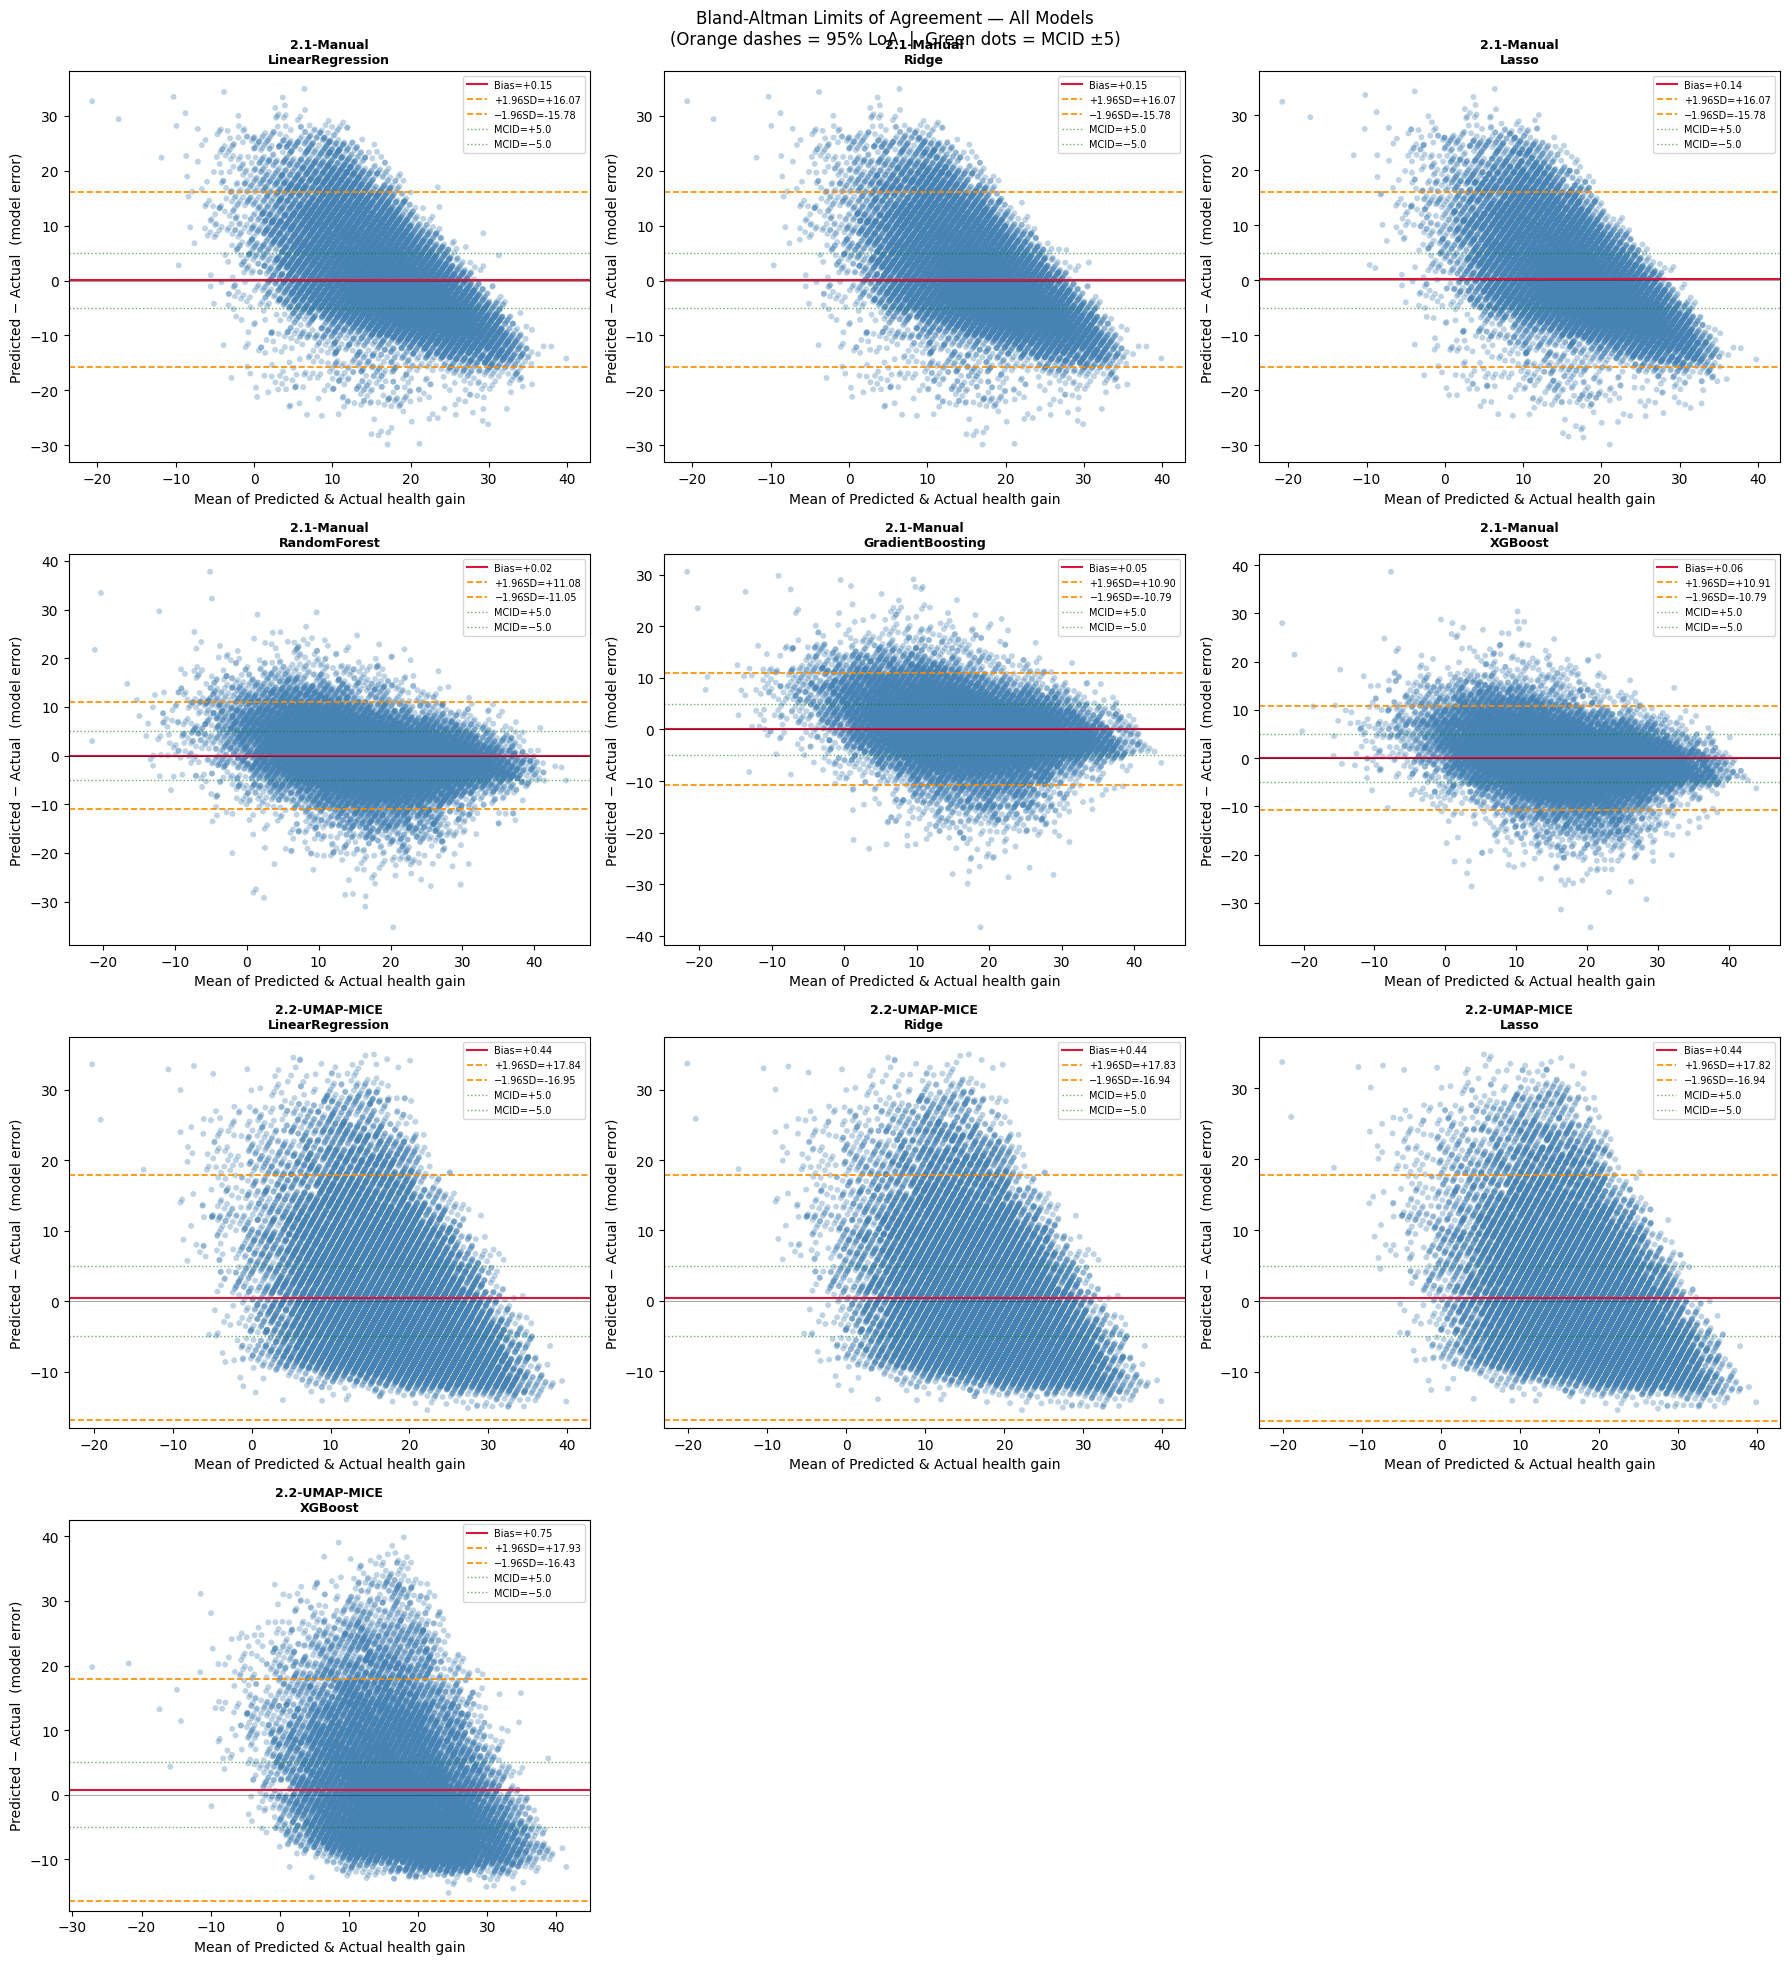


=== Bland-Altman Summary (all models, sorted by narrowest LoA) ===



,Dataset,Model,Bias,LoA Upper (+1.96SD),LoA Lower (−1.96SD),LoA Width,LoA Within MCID?
0,2.1-Manual,GradientBoosting,0.0544,10.9021,-10.7932,21.6953,✗ No
1,2.1-Manual,XGBoost,0.0597,10.9075,-10.7882,21.6957,✗ No
2,2.1-Manual,RandomForest,0.0156,11.0815,-11.0503,22.1318,✗ No
3,2.1-Manual,Ridge,0.1452,16.0666,-15.7762,31.8428,✗ No
4,2.1-Manual,Lasso,0.1420,16.0686,-15.7846,31.8532,✗ No
5,2.1-Manual,LinearRegression,0.1464,16.0730,-15.7802,31.8532,✗ No
6,2.2-UMAP-MICE,XGBoost,0.7497,17.9324,-16.4331,34.3655,✗ No
7,2.2-UMAP-MICE,Lasso,0.4383,17.8215,-16.9448,34.7663,✗ No
8,2.2-UMAP-MICE,Ridge,0.4419,17.8282,-16.9443,34.7725,✗ No
9,2.2-UMAP-MICE,LinearRegression,0.4436,17.8372,-16.9500,34.7872,✗ No



NOTE: Limits of agreement within MCID (±5.0) means the model is precise
      enough that 95% of individual predictions are clinically meaningful.


In [ ]:
def bland_altman_stats(y_true, y_pred):
    """Return mean bias and limits of agreement."""
    diff      = y_pred - y_true
    mean_pair = (y_pred + y_true) / 2
    bias      = diff.mean()
    loa_sd    = diff.std()
    loa_upper = bias + 1.96 * loa_sd
    loa_lower = bias - 1.96 * loa_sd
    return mean_pair, diff, bias, loa_upper, loa_lower


def plot_bland_altman(ax, mean_pair, diff, bias, loa_upper, loa_lower, title):
    ax.scatter(mean_pair, diff, alpha=0.35, s=18, color='steelblue', edgecolors='none')
    ax.axhline(bias,      color='crimson',  linestyle='-',  linewidth=1.5, label=f'Bias={bias:+.2f}')
    ax.axhline(loa_upper, color='darkorange', linestyle='--', linewidth=1.2, label=f'+1.96SD={loa_upper:+.2f}')
    ax.axhline(loa_lower, color='darkorange', linestyle='--', linewidth=1.2, label=f'−1.96SD={loa_lower:+.2f}')
    ax.axhline(MCID,  color='green', linestyle=':', linewidth=1.0, alpha=0.6, label=f'MCID=+{MCID}')
    ax.axhline(-MCID, color='green', linestyle=':', linewidth=1.0, alpha=0.6, label=f'MCID=−{MCID}')
    ax.axhline(0, color='black', linewidth=0.6, alpha=0.4)
    ax.set_xlabel('Mean of Predicted & Actual health gain')
    ax.set_ylabel('Predicted − Actual  (model error)')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, loc='upper right')


# ── Plot Bland-Altman for every (dataset × model) pair ───────────────────────
all_runs = [(ds, mdl, res)
            for ds, md in all_results.items()
            for mdl, res in md.items()]

n        = len(all_runs)
ncols    = 3
nrows    = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes_flat = axes.flatten() if n > 1 else [axes]
fig.suptitle('Bland-Altman Limits of Agreement — All Models\n(Orange dashes = 95% LoA  |  Green dots = MCID ±5)', fontsize=12)

ba_summary = []
for i, (ds, mdl, res) in enumerate(all_runs):
    mp, diff, bias, lou, lol = bland_altman_stats(res['y_test'], res['y_pred'])
    plot_bland_altman(axes_flat[i], mp, diff, bias, lou, lol, f'{ds}\n{mdl}')
    ba_summary.append({
        'Dataset': ds, 'Model': mdl,
        'Bias': round(bias, 4),
        'LoA Upper (+1.96SD)': round(lou, 4),
        'LoA Lower (−1.96SD)': round(lol, 4),
        'LoA Width': round(lou - lol, 4),
        'LoA Within MCID?': '✓ Yes' if (lou <= MCID and lol >= -MCID) else '✗ No',
    })

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

# ── Summary table (Polars) ────────────────────────────────────────────────────
ba_df = pl.DataFrame(ba_summary).sort('LoA Width')
print('\n=== Bland-Altman Summary (all models, sorted by narrowest LoA) ===\n')
print(ba_df)

print(f'\nNOTE: Limits of agreement within MCID (±{MCID}) means the model is precise')
print(f'      enough that 95% of individual predictions are clinically meaningful.')

---
## 2. MCID-Based Confusion Matrix

Because we have **no binary outcome**, we create one using clinical knowledge:

$$\text{Clinically improved} = \begin{cases} 1 & \text{if health\_gain} \geq \text{MCID} \\ 0 & \text{otherwise} \end{cases}$$

This transforms the regression prediction into a **clinically meaningful classification**.

### Asymmetric cost reasoning

Standard layout — rows = Actual, columns = Predicted, negative class top-left:

| | Pred: No benefit | Pred: Benefit |
|---|---|---|
| **Actual: No benefit** | TN — correct refusal | FP — unnecessary surgery |
| **Actual: Benefit** | **FN — denied beneficial surgery ← worst outcome** | TP — correct approval |

A **False Negative** (denying surgery to someone who would genuinely improve) is arguably worse than a False Positive. We therefore compute F₂ score (weights recall 2× higher than precision) alongside standard metrics.

$$F_{\beta} = (1 + \beta^2) \cdot \frac{\text{Precision} \times \text{Recall}}{\beta^2 \cdot \text{Precision} + \text{Recall}}$$

> **F₂ (β=2)**: Recall is twice as important as Precision — reflects NHS clinical priorities.


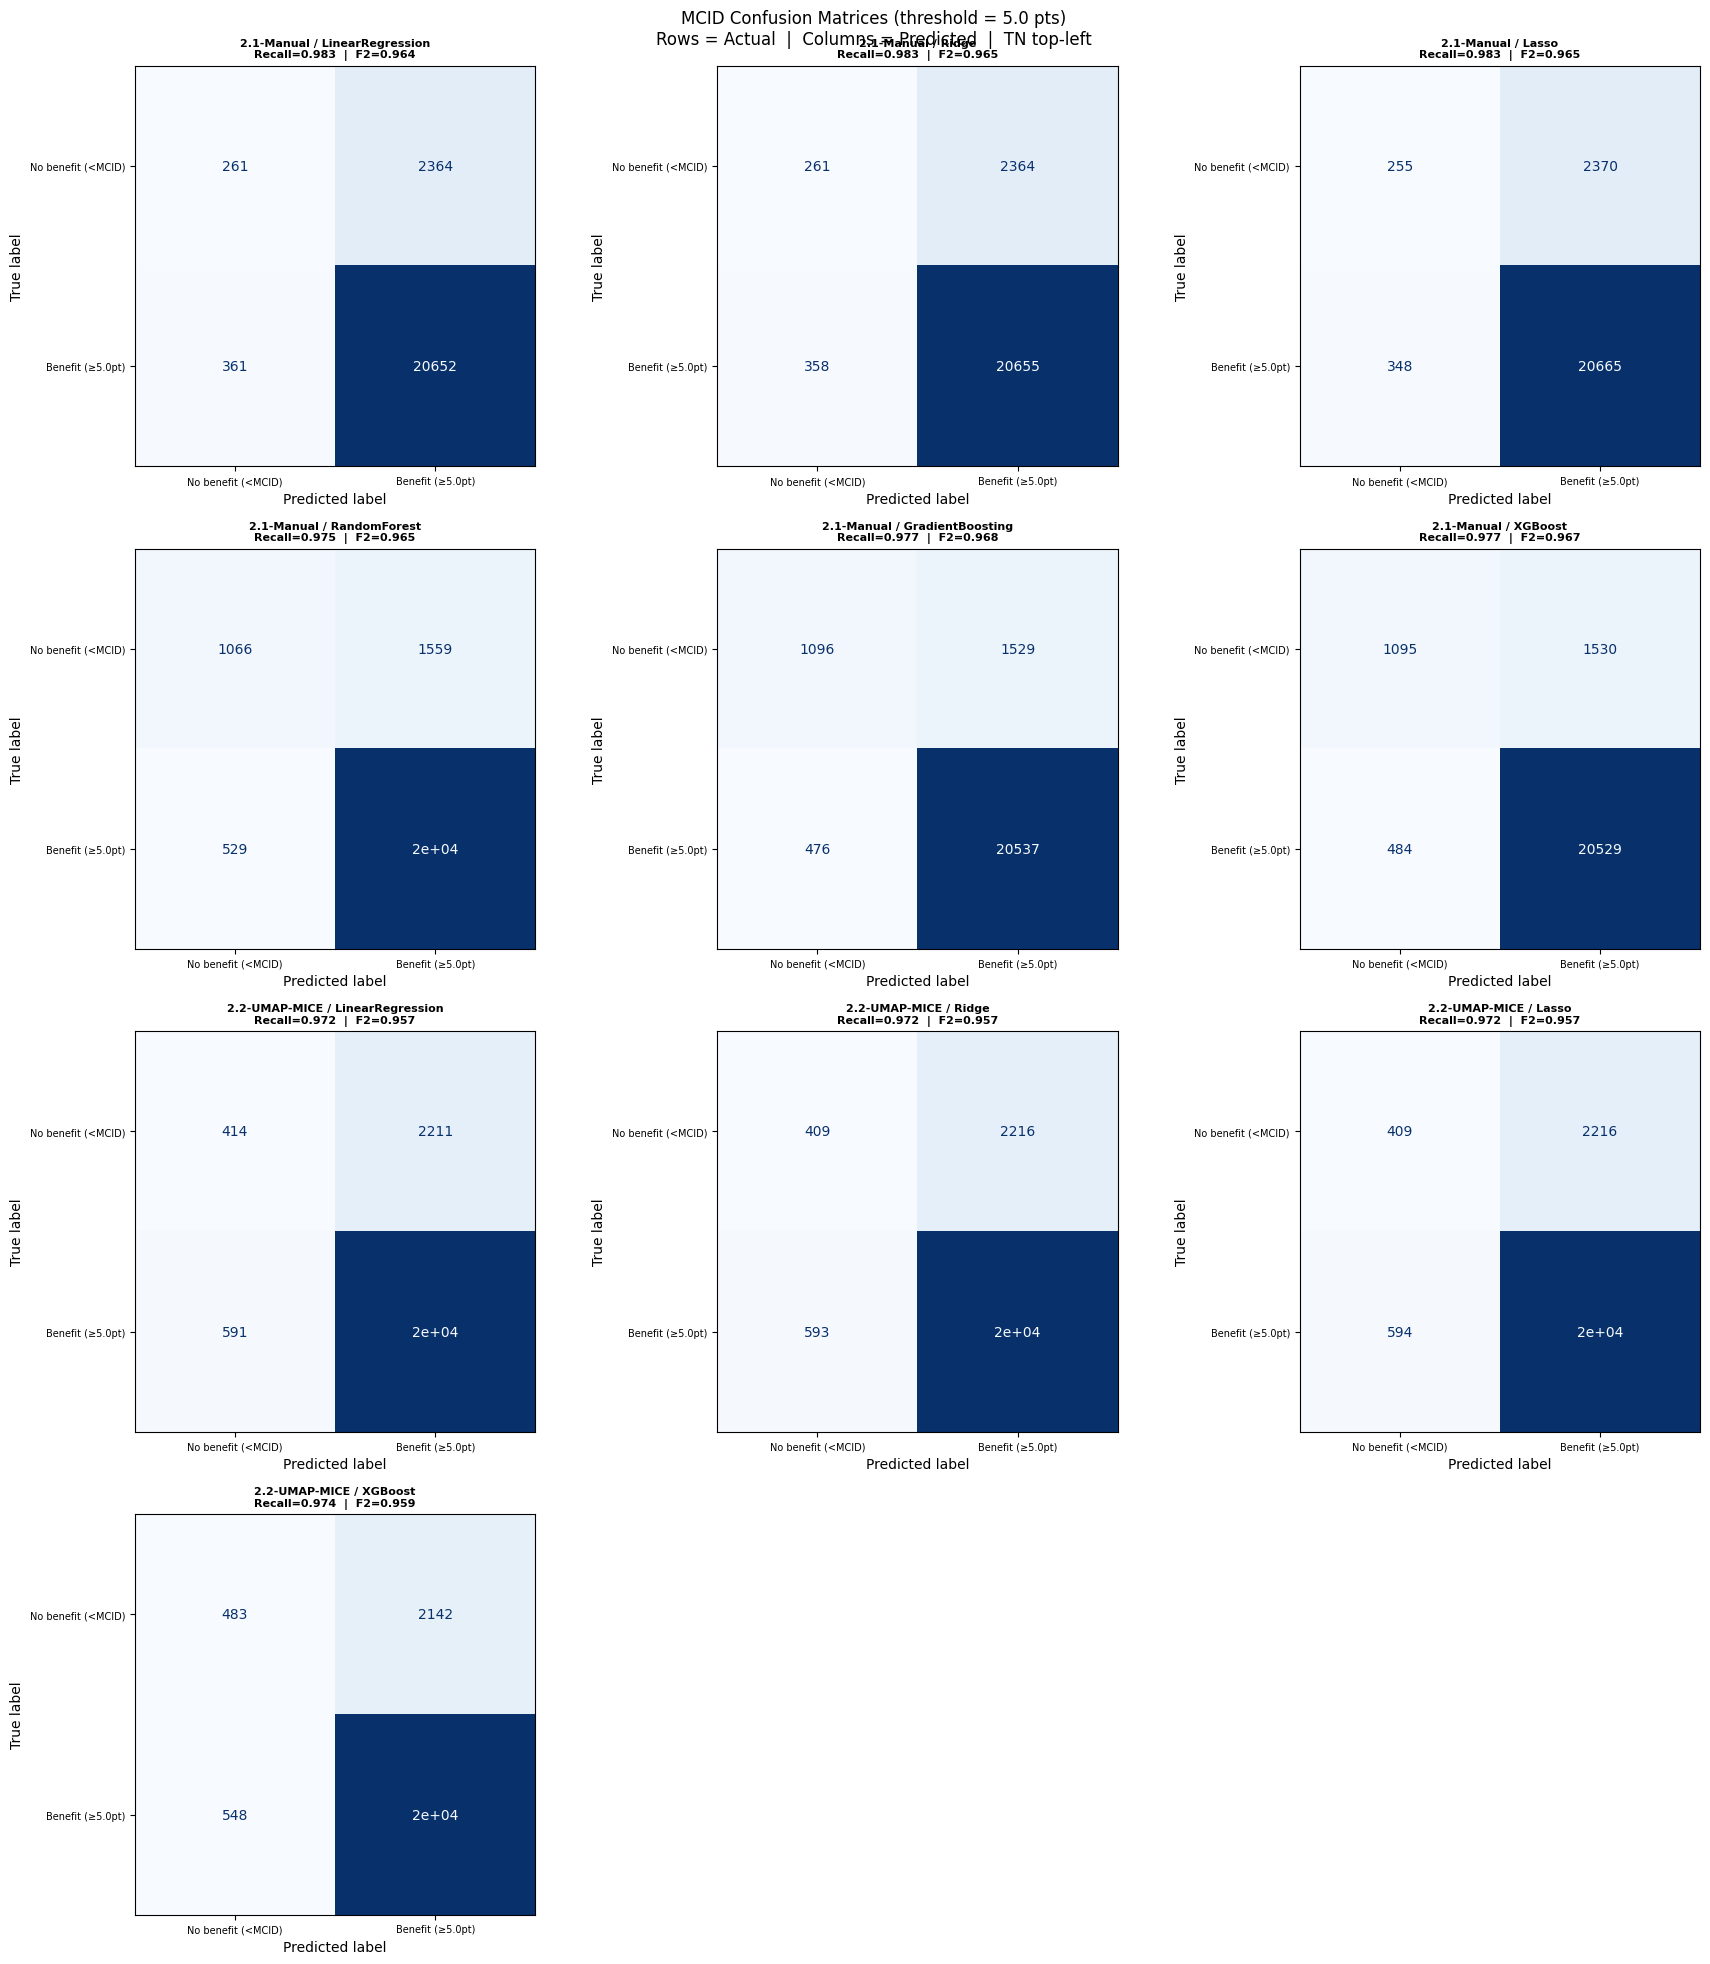


=== MCID Classification Summary (sorted by F2) ===



,Dataset,Model,TP,TN,FP,FN,Precision,Recall (Sensitivity),Specificity,NPV,F1,F2 (β=2)
0,2.1-Manual,GradientBoosting,20537,1096,1529,476,0.930700,0.977300,0.417500,0.697200,0.953500,0.967600
1,2.1-Manual,XGBoost,20529,1095,1530,484,0.930600,0.977000,0.417100,0.693500,0.953200,0.967300
2,2.1-Manual,RandomForest,20484,1066,1559,529,0.929300,0.974800,0.406100,0.668300,0.951500,0.965400
3,2.1-Manual,Lasso,20665,255,2370,348,0.897100,0.983400,0.097100,0.422900,0.938300,0.964900
4,2.1-Manual,Ridge,20655,261,2364,358,0.897300,0.983000,0.099400,0.421600,0.938200,0.964500
5,2.1-Manual,LinearRegression,20652,261,2364,361,0.897300,0.982800,0.099400,0.419600,0.938100,0.964400
6,2.2-UMAP-MICE,XGBoost,20465,483,2142,548,0.905300,0.973900,0.184000,0.468500,0.938300,0.959400
7,2.2-UMAP-MICE,LinearRegression,20422,414,2211,591,0.902300,0.971900,0.157700,0.411900,0.935800,0.957100
8,2.2-UMAP-MICE,Ridge,20420,409,2216,593,0.902100,0.971800,0.155800,0.408200,0.935600,0.957000
9,2.2-UMAP-MICE,Lasso,20419,409,2216,594,0.902100,0.971700,0.155800,0.407800,0.935600,0.957000



Interpretation guide:
  FN = denied beneficial surgery (worst outcome) → maximise Recall
  FP = unnecessary surgery → monitor Precision
  F2 (β=2) = recall weighted 2× — use as primary clinical metric


In [ ]:
from sklearn.metrics import fbeta_score, precision_score, recall_score, f1_score

def mcid_classification_metrics(y_true, y_pred, threshold=MCID):
    """Binarise using MCID threshold and return classification metrics."""
    y_true_bin = (y_true >= threshold).astype(int)
    y_pred_bin = (y_pred >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()
    prec   = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    rec    = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1     = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    f2     = fbeta_score(y_true_bin, y_pred_bin, beta=2, zero_division=0)
    spec   = tn / (tn + fp) if (tn + fp) > 0 else 0
    ppv    = prec
    npv    = tn / (tn + fn) if (tn + fn) > 0 else 0
    return {
        'y_true_bin': y_true_bin, 'y_pred_bin': y_pred_bin,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'Precision': prec, 'Recall (Sensitivity)': rec,
        'Specificity': spec, 'NPV': npv,
        'F1': f1, 'F2 (β=2)': f2,
    }


# ── Confusion matrices — all models ──────────────────────────────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes_flat = axes.flatten() if n > 1 else [axes]
fig.suptitle(f'MCID Confusion Matrices (threshold = {MCID} pts)\n'
             'Rows = Actual  |  Columns = Predicted  |  TN top-left', fontsize=12)

cm_summary = []
for i, (ds, mdl, res) in enumerate(all_runs):
    m = mcid_classification_metrics(res['y_test'], res['y_pred'])
    cm_summary.append({
        'Dataset': ds, 'Model': mdl,
        'TP': m['TP'], 'TN': m['TN'], 'FP': m['FP'], 'FN': m['FN'],
        'Precision':            round(m['Precision'], 4),
        'Recall (Sensitivity)': round(m['Recall (Sensitivity)'], 4),
        'Specificity':          round(m['Specificity'], 4),
        'NPV':                  round(m['NPV'], 4),
        'F1':                   round(m['F1'], 4),
        'F2 (β=2)':             round(m['F2 (β=2)'], 4),
    })

    cm = confusion_matrix(m['y_true_bin'], m['y_pred_bin'], labels=[0, 1])
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['No benefit (<MCID)', f'Benefit (≥{MCID}pt)'],
    )
    disp.plot(ax=axes_flat[i], colorbar=False, cmap='Blues')
    axes_flat[i].set_title(
        f'{ds} / {mdl}\n'
        f'Recall={m["Recall (Sensitivity)"]:.3f}  |  F2={m["F2 (β=2)"]:.3f}',
        fontsize=8, fontweight='bold',
    )
    axes_flat[i].tick_params(axis='x', labelsize=7)
    axes_flat[i].tick_params(axis='y', labelsize=7)

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

# ── Summary table (Polars) sorted by F2 ──────────────────────────────────────
cm_df = pl.DataFrame(cm_summary).sort('F2 (β=2)', descending=True)
print(f'\n=== MCID Classification Summary (sorted by F2) ===\n')
print(cm_df)

print('\nInterpretation guide:')
print(f'  FN = denied beneficial surgery (worst outcome) → maximise Recall')
print(f'  FP = unnecessary surgery → monitor Precision')
print(f'  F2 (β=2) = recall weighted 2× — use as primary clinical metric')

### 2b. Threshold Optimisation to Reduce False Negatives

At the default MCID threshold the model may deny surgery to patients who genuinely benefit (**FN**).  
Because the regression output is a continuous score, we can **lower the decision boundary** to trade fewer FN for more FP.

**Strategy:** sweep every threshold from `y_pred.min()` to `y_pred.max()`, compute FN, Recall & F₂ at each point, then select the cut-point that **maximises F₂** (recall-weighted 2×).

| Default threshold | Optimal threshold |
|---|---|
| Set to MCID = 5 pts | Set to maximise F₂ |
| May miss borderline patients | Fewer denied patients; more FP |

### 2c. AUROC & Precision-Recall Curves — All Models

The continuous regression output acts as a **ranking score** for benefit classification:

- **ROC curve** (TPR vs FPR) + AUROC — measures discriminative ability regardless of threshold
- **Precision-Recall curve** + Average Precision — more informative for imbalanced classes  
  (benefit prevalence ≠ 50%)
- **F₂ iso-curves** overlaid on PR plots — show which PR combinations satisfy clinical targets


=== Threshold Comparison  [2.1-Manual × GradientBoosting] ===

Metric          MCID threshold (5.0 pts)      Optimal threshold (0.38 pts)
------------------------------------------------------------------------
FN              480                           45                          
FP              1523                          2278                        
TP              2.053e+04                     2.097e+04                   
TN              1102                          347                         
Recall          0.9772                        0.9979                      
Precision       0.9309                        0.902                       
F2              0.9676                        0.9771                      

  → Optimal threshold lowers decision boundary by 4.62 pts
  → FN reduced by 435 patients  (fewer denied surgeries)
  → FP increased by 755 patients  (more unnecessary surgeries)


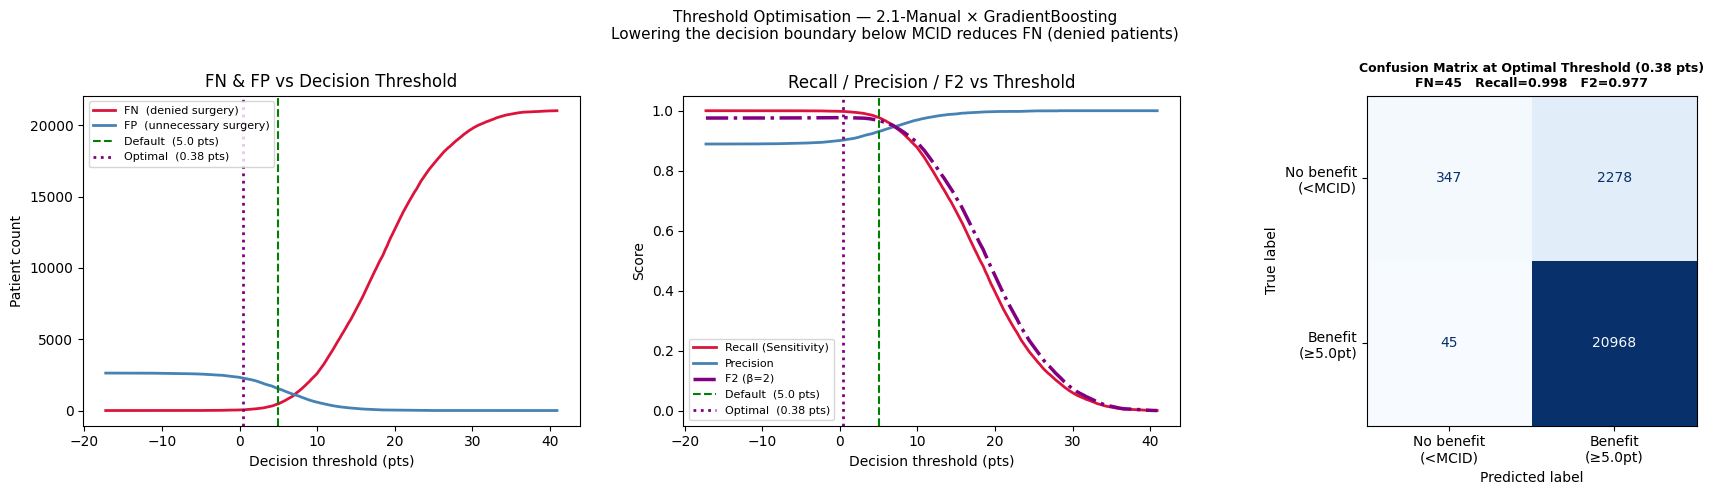

In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve, average_precision_score

# ── Threshold sweep on the WINNER model ────────────────────────────────────────
y_true_bin_w = (y_test >= MCID).astype(int)

thresholds_sweep = np.linspace(y_pred.min(), y_pred.max(), 400)
thr_rows = []
for t in thresholds_sweep:
    y_pb = (y_pred >= t).astype(int)
    cm_t = confusion_matrix(y_true_bin_w, y_pb, labels=[0, 1])
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    rec_t  = recall_score(y_true_bin_w,  y_pb, zero_division=0)
    prec_t = precision_score(y_true_bin_w, y_pb, zero_division=0)
    f2_t   = fbeta_score(y_true_bin_w,   y_pb, beta=2, zero_division=0)
    thr_rows.append({'Threshold': t, 'TP': tp_t, 'TN': tn_t, 'FP': fp_t, 'FN': fn_t,
                     'Recall': rec_t, 'Precision': prec_t, 'F2': f2_t})

thr_df = pl.DataFrame(thr_rows)

# Best threshold by F2 (argmax)
best_thr_idx = thr_df['F2'].arg_max()
opt_thr      = thr_df['Threshold'][best_thr_idx]
opt_row      = thr_df.row(best_thr_idx, named=True)

# Row closest to MCID (default threshold)
mcid_idx_arr = (thr_df['Threshold'] - MCID).abs().arg_min()
mcid_row     = thr_df.row(mcid_idx_arr, named=True)

# ── Print comparison table ─────────────────────────────────────────────────────
print(f'=== Threshold Comparison  [{best_dataset} × {best_name}] ===\n')
print(f'{"Metric":<14}  {"MCID threshold (" + str(MCID) + " pts)":<28}  {"Optimal threshold (" + f"{opt_thr:.2f}" + " pts)":<28}')
print('-' * 72)
for col in ['FN', 'FP', 'TP', 'TN', 'Recall', 'Precision', 'F2']:
    print(f'{col:<14}  {mcid_row[col]:<28.4g}  {opt_row[col]:<28.4g}')

fn_saved = int(mcid_row['FN'] - opt_row['FN'])
print(f'\n  → Optimal threshold lowers decision boundary by {MCID - opt_thr:.2f} pts')
print(f'  → FN reduced by {fn_saved} patients  (fewer denied surgeries)')
print(f'  → FP increased by {int(opt_row["FP"] - mcid_row["FP"])} patients  (more unnecessary surgeries)')

# ── Figure: threshold sweep curves + optimal confusion matrix ─────────────────
thr_np  = thr_df['Threshold'].to_numpy()
fn_np   = thr_df['FN'].to_numpy()
fp_np   = thr_df['FP'].to_numpy()
rec_np  = thr_df['Recall'].to_numpy()
prec_np = thr_df['Precision'].to_numpy()
f2_np   = thr_df['F2'].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Threshold Optimisation — {best_dataset} × {best_name}\n'
             f'Lowering the decision boundary below MCID reduces FN (denied patients)',
             fontsize=11)

axes[0].plot(thr_np, fn_np, color='crimson',   linewidth=2, label='FN  (denied surgery)')
axes[0].plot(thr_np, fp_np, color='steelblue', linewidth=2, label='FP  (unnecessary surgery)')
axes[0].axvline(MCID,    color='green',  linestyle='--', linewidth=1.5, label=f'Default  ({MCID} pts)')
axes[0].axvline(opt_thr, color='purple', linestyle=':',  linewidth=2,   label=f'Optimal  ({opt_thr:.2f} pts)')
axes[0].set_xlabel('Decision threshold (pts)'); axes[0].set_ylabel('Patient count')
axes[0].set_title('FN & FP vs Decision Threshold'); axes[0].legend(fontsize=8)

axes[1].plot(thr_np, rec_np,  color='crimson',   linewidth=2, label='Recall (Sensitivity)')
axes[1].plot(thr_np, prec_np, color='steelblue', linewidth=2, label='Precision')
axes[1].plot(thr_np, f2_np,   color='purple',    linewidth=2.5, label='F2 (β=2)', linestyle='-.')
axes[1].axvline(MCID,    color='green',  linestyle='--', linewidth=1.5, label=f'Default  ({MCID} pts)')
axes[1].axvline(opt_thr, color='purple', linestyle=':',  linewidth=2,   label=f'Optimal  ({opt_thr:.2f} pts)')
axes[1].set_xlabel('Decision threshold (pts)'); axes[1].set_ylabel('Score')
axes[1].set_title('Recall / Precision / F2 vs Threshold'); axes[1].legend(fontsize=8)

y_pred_opt = (y_pred >= opt_thr).astype(int)
cm_opt = confusion_matrix(y_true_bin_w, y_pred_opt, labels=[0, 1])
disp_opt = ConfusionMatrixDisplay(cm_opt, display_labels=['No benefit\n(<MCID)', f'Benefit\n(≥{MCID}pt)'])
disp_opt.plot(ax=axes[2], colorbar=False, cmap='Blues')
axes[2].set_title(
    f'Confusion Matrix at Optimal Threshold ({opt_thr:.2f} pts)\n'
    f'FN={int(opt_row["FN"])}   Recall={opt_row["Recall"]:.3f}   F2={opt_row["F2"]:.3f}',
    fontsize=9, fontweight='bold',
)

plt.tight_layout()
plt.show()

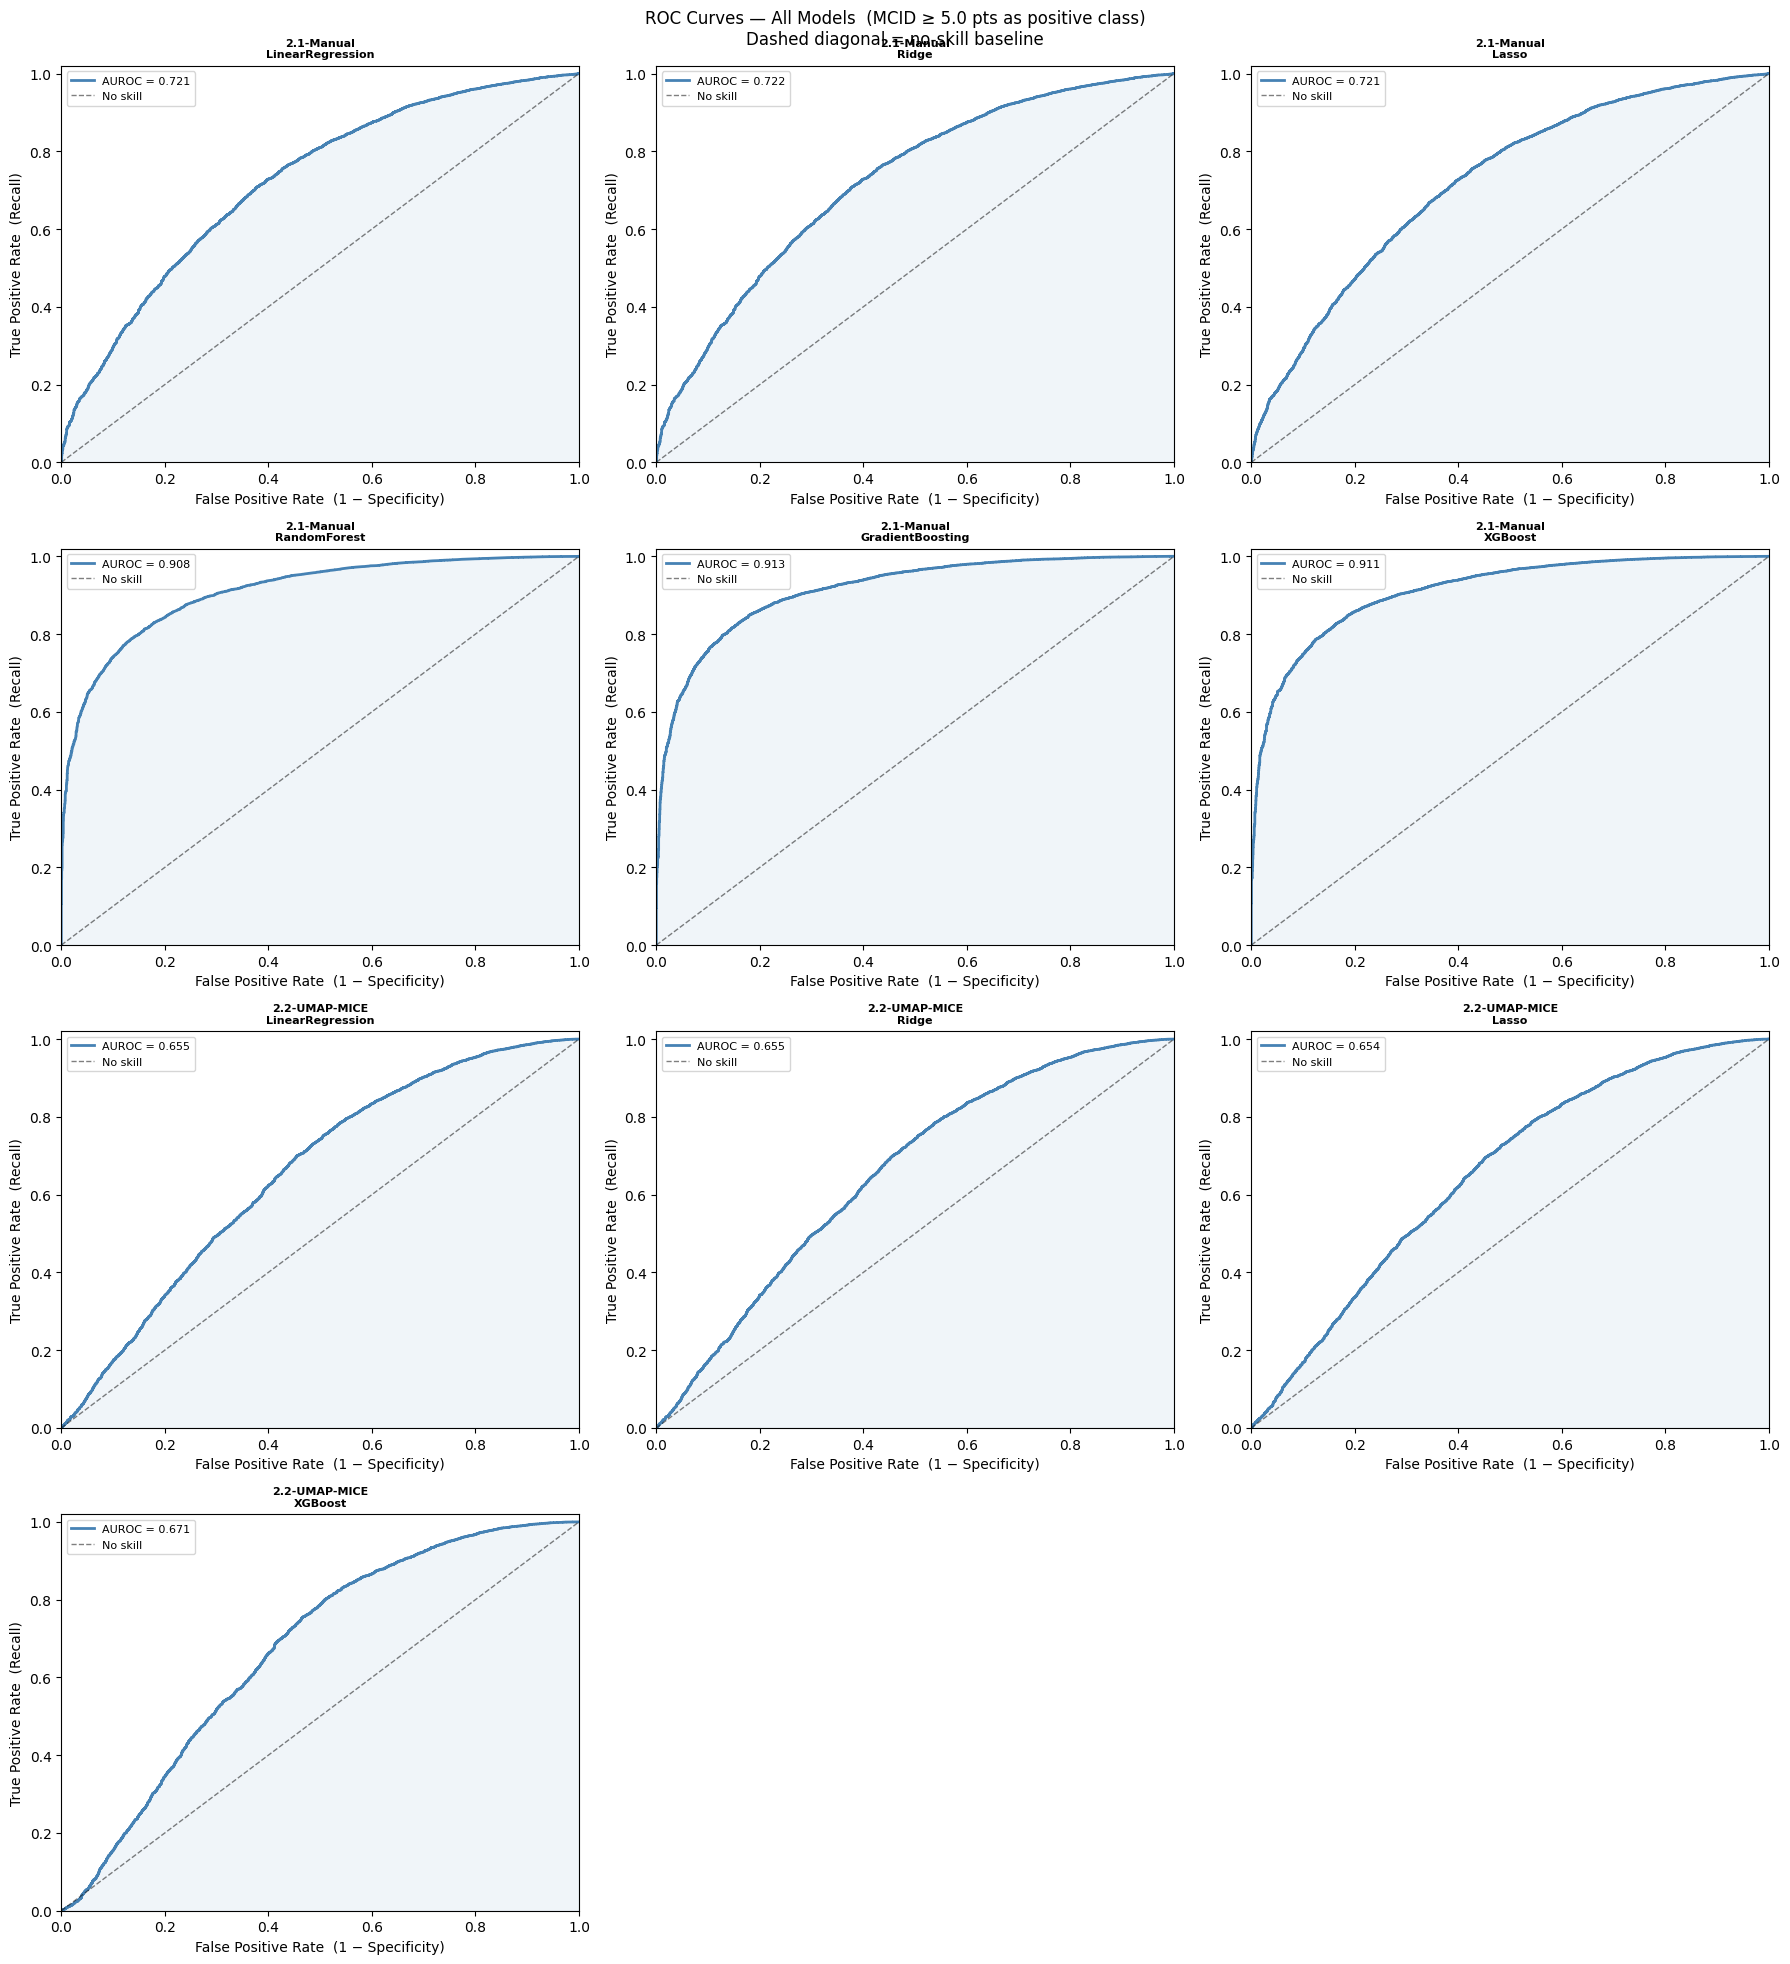

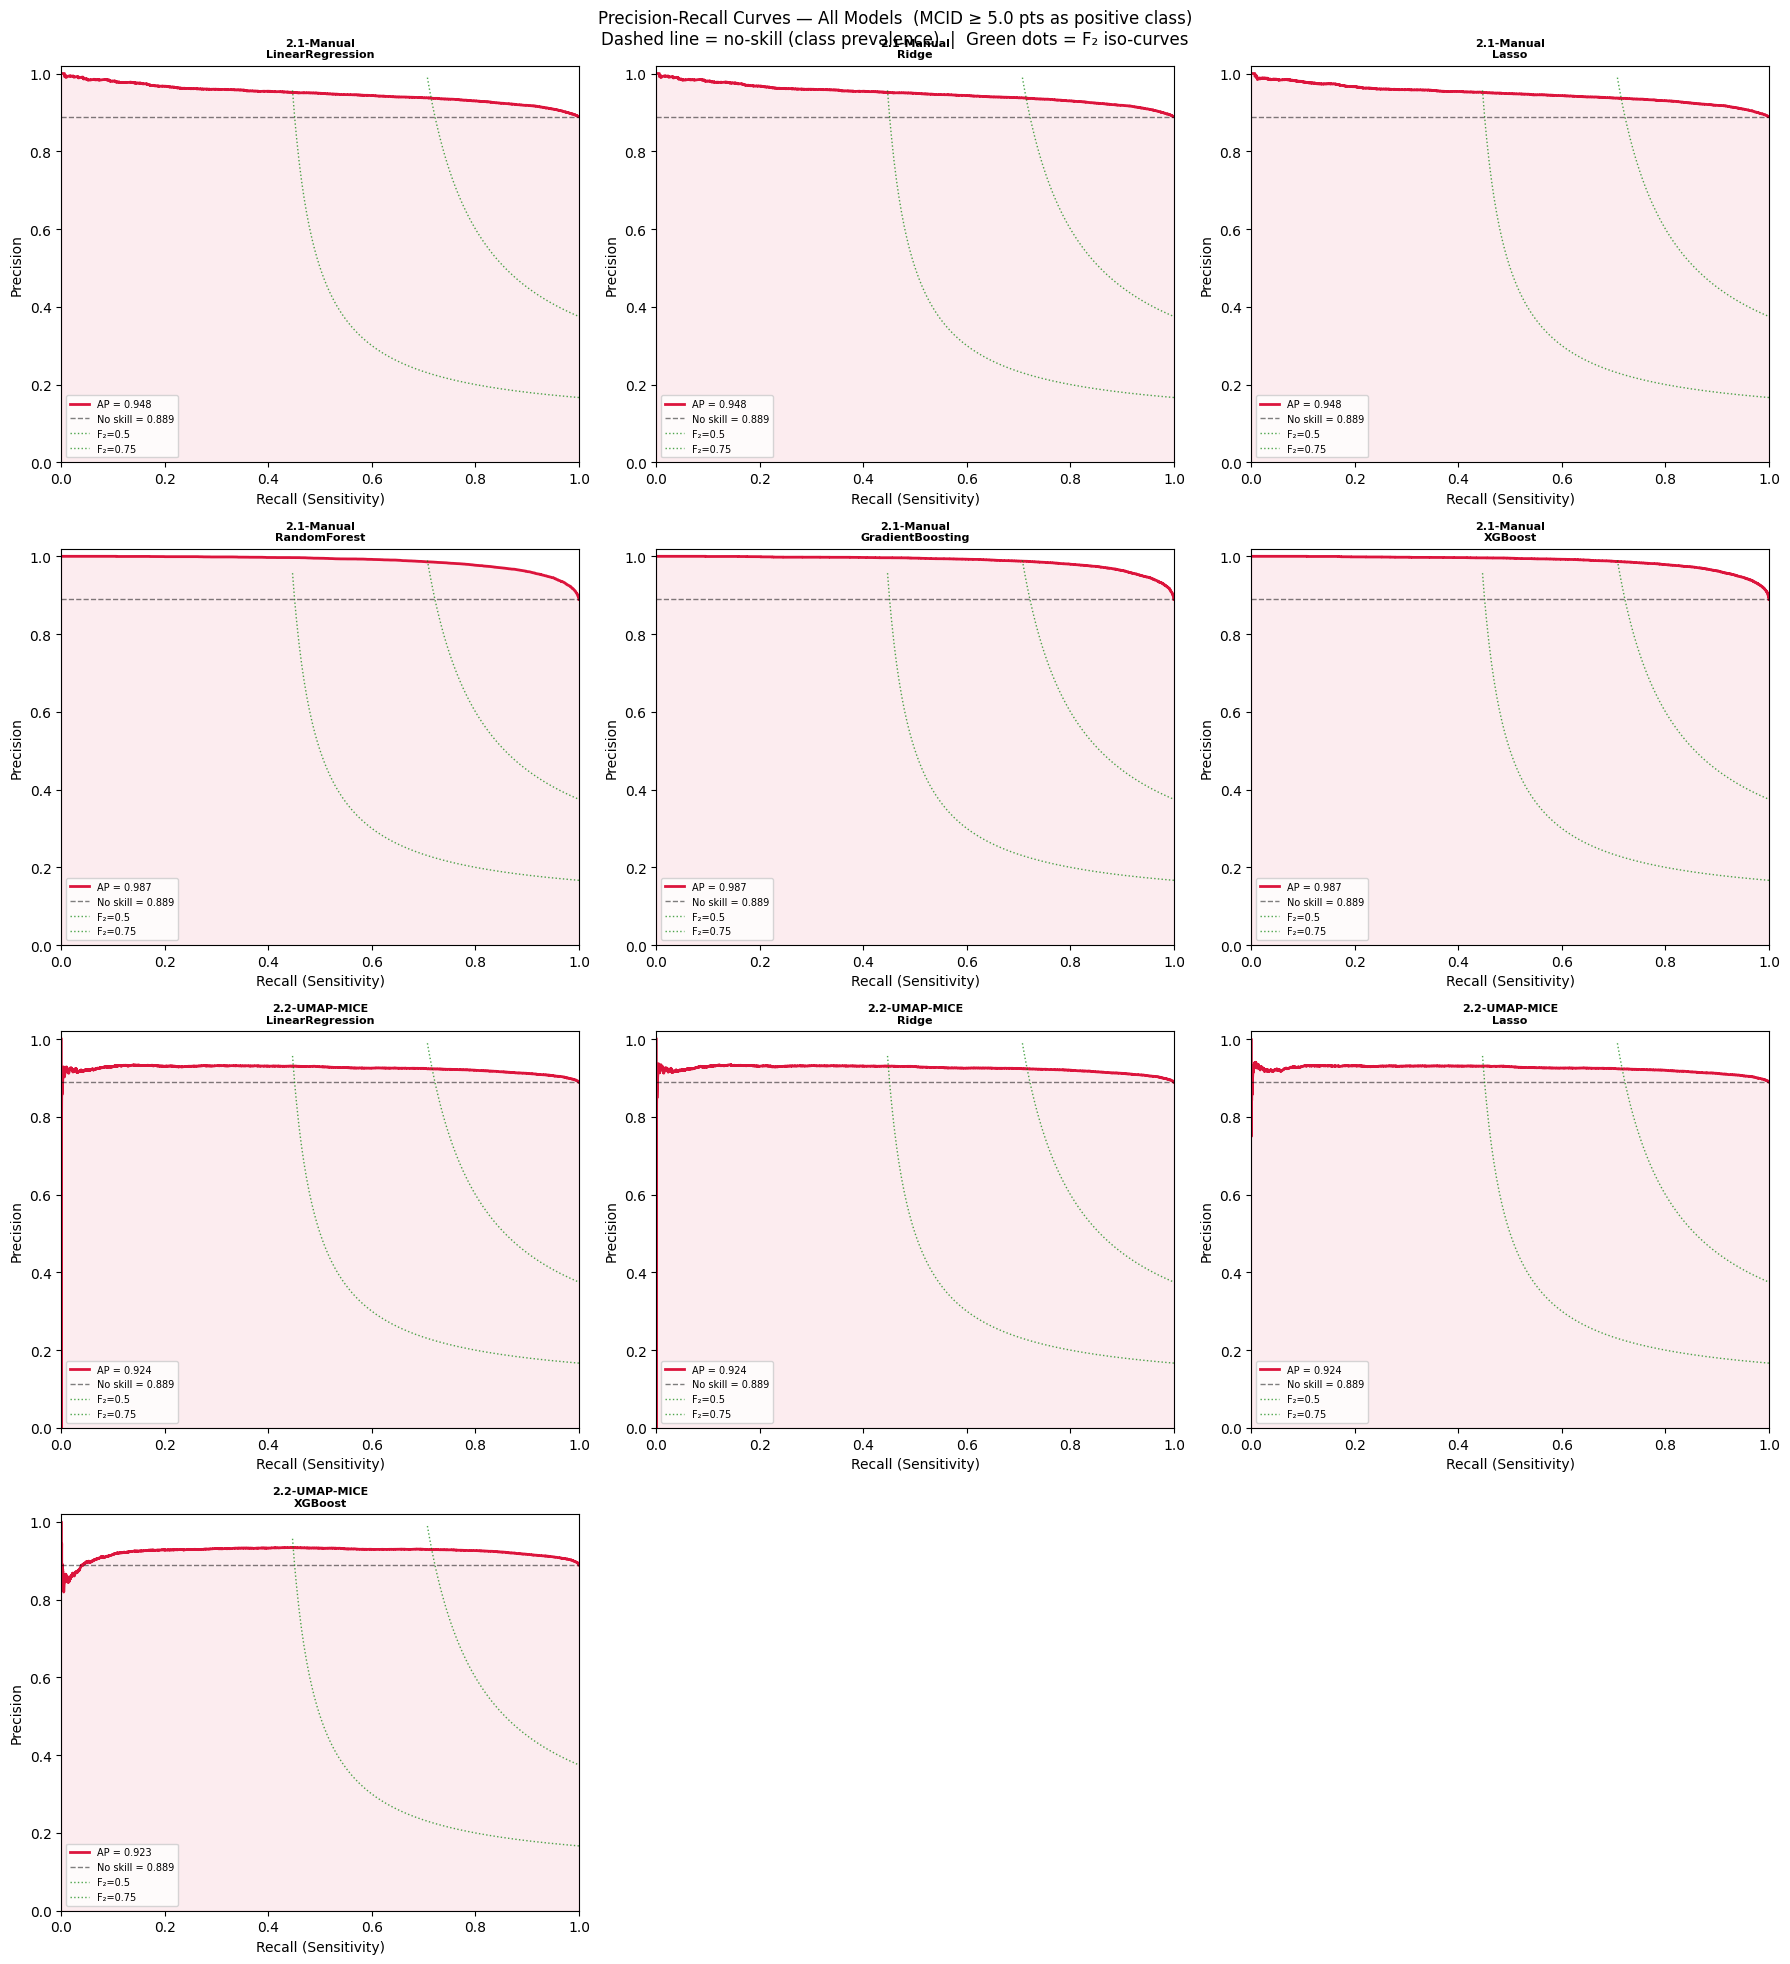


=== AUROC & Average Precision Summary ===



,Dataset,Model,AUROC,Avg Precision,Prevalence (%)
0,2.1-Manual,GradientBoosting,0.913300,0.987400,88.900000
1,2.1-Manual,XGBoost,0.911500,0.987100,88.900000
2,2.1-Manual,RandomForest,0.908000,0.986800,88.900000
3,2.1-Manual,Ridge,0.721700,0.948300,88.900000
4,2.1-Manual,LinearRegression,0.721500,0.948200,88.900000
5,2.1-Manual,Lasso,0.721000,0.947700,88.900000
6,2.2-UMAP-MICE,XGBoost,0.671400,0.922700,88.900000
7,2.2-UMAP-MICE,Ridge,0.654800,0.923900,88.900000
8,2.2-UMAP-MICE,LinearRegression,0.654700,0.923800,88.900000
9,2.2-UMAP-MICE,Lasso,0.654300,0.924100,88.900000



Interpretation:
  AUROC   0.9–1.0 = excellent  |  0.8–0.9 = good  |  0.7–0.8 = fair  |  <0.7 = poor
  Avg Precision (AP) = area under PR curve — preferred when positive class is minority.
  Models above the No-Skill line on the PR plot have genuine discriminative power.


In [ ]:
# ── ROC curves + AUROC — All Models ───────────────────────────────────────────
auroc_summary = []

fig_roc, axes_roc = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes_roc_flat = axes_roc.flatten() if n > 1 else [axes_roc]
fig_roc.suptitle(
    f'ROC Curves — All Models  (MCID ≥ {MCID} pts as positive class)\n'
    'Dashed diagonal = no-skill baseline',
    fontsize=12,
)

for i, (ds, mdl, res) in enumerate(all_runs):
    y_t_bin  = (res['y_test'] >= MCID).astype(int)
    y_scores = res['y_pred']

    try:
        auroc = roc_auc_score(y_t_bin, y_scores)
        fpr, tpr, _ = roc_curve(y_t_bin, y_scores)
    except ValueError:
        auroc, fpr, tpr = np.nan, np.array([0, 1]), np.array([0, 1])

    ap = average_precision_score(y_t_bin, y_scores) if not np.isnan(auroc) else np.nan

    auroc_summary.append({
        'Dataset': ds, 'Model': mdl,
        'AUROC':           round(float(auroc), 4),
        'Avg Precision':   round(float(ap), 4),
        'Prevalence (%)':  round(y_t_bin.mean() * 100, 1),
    })

    ax = axes_roc_flat[i]
    ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUROC = {auroc:.3f}')
    ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='No skill')
    ax.fill_between(fpr, tpr, alpha=0.08, color='steelblue')
    ax.set_xlabel('False Positive Rate  (1 − Specificity)')
    ax.set_ylabel('True Positive Rate  (Recall)')
    ax.set_title(f'{ds}\n{mdl}', fontsize=8, fontweight='bold')
    ax.legend(fontsize=8); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

for j in range(i + 1, len(axes_roc_flat)):
    axes_roc_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

# ── Precision-Recall curves — All Models ──────────────────────────────────────
fig_pr, axes_pr = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes_pr_flat = axes_pr.flatten() if n > 1 else [axes_pr]
fig_pr.suptitle(
    f'Precision-Recall Curves — All Models  (MCID ≥ {MCID} pts as positive class)\n'
    'Dashed line = no-skill (class prevalence)  |  Green dots = F₂ iso-curves',
    fontsize=12,
)

for i, (ds, mdl, res) in enumerate(all_runs):
    y_t_bin  = (res['y_test'] >= MCID).astype(int)
    y_scores = res['y_pred']
    prevalence_i = y_t_bin.mean()

    try:
        prec_c, rec_c, _ = precision_recall_curve(y_t_bin, y_scores)
        ap = average_precision_score(y_t_bin, y_scores)
    except ValueError:
        prec_c, rec_c, ap = np.array([1, 0]), np.array([0, 1]), np.nan

    ax = axes_pr_flat[i]
    ax.plot(rec_c, prec_c, color='crimson', linewidth=2, label=f'AP = {ap:.3f}')
    ax.axhline(prevalence_i, color='k', linestyle='--', linewidth=1, alpha=0.5,
               label=f'No skill = {prevalence_i:.3f}')
    ax.fill_between(rec_c, prec_c, alpha=0.08, color='crimson')

    r_iso = np.linspace(0.01, 1.0, 400)
    for f2_iso, lbl in [(0.5, 'F₂=0.5'), (0.75, 'F₂=0.75')]:
        denom = 5 * r_iso - 4 * f2_iso
        p_iso = np.where(denom > 1e-8, f2_iso * r_iso / denom, np.nan)
        valid = (p_iso >= 0) & (p_iso <= 1)
        ax.plot(r_iso[valid], p_iso[valid], 'g:', linewidth=1.0, alpha=0.7, label=lbl)

    ax.set_xlabel('Recall (Sensitivity)')
    ax.set_ylabel('Precision')
    ax.set_title(f'{ds}\n{mdl}', fontsize=8, fontweight='bold')
    ax.legend(fontsize=7); ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

for j in range(i + 1, len(axes_pr_flat)):
    axes_pr_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

# ── Summary table (Polars): AUROC + AP across all models ─────────────────────
auroc_df = pl.DataFrame(auroc_summary).sort('AUROC', descending=True)
print('\n=== AUROC & Average Precision Summary ===\n')
print(auroc_df)

print('\nInterpretation:')
print('  AUROC   0.9–1.0 = excellent  |  0.8–0.9 = good  |  0.7–0.8 = fair  |  <0.7 = poor')
print('  Avg Precision (AP) = area under PR curve — preferred when positive class is minority.')

---
## 3. Calibration by Predicted Score Decile

A model can have good global RMSE but be **systematically miscalibrated at the tails** — over-predicting for high-gain patients and under-predicting for low-gain patients.

**Method:**
1. Bin the test set into 10 equal groups by *predicted* health gain
2. For each bin: compare mean(predicted) vs mean(actual)
3. A perfectly calibrated model lies on the diagonal

**Why this matters clinically:**  
The patients at the extremes — those with very low predicted gain (borderline cases) and very high predicted gain — are the ones where calibration errors have the largest impact on surgical decisions.

> The **calibration slope** (regression of mean-actual on mean-predicted) should ideally = 1.0.  
> A slope < 1 indicates **regression-to-the-mean bias** — a very common failure mode in healthcare prediction models.

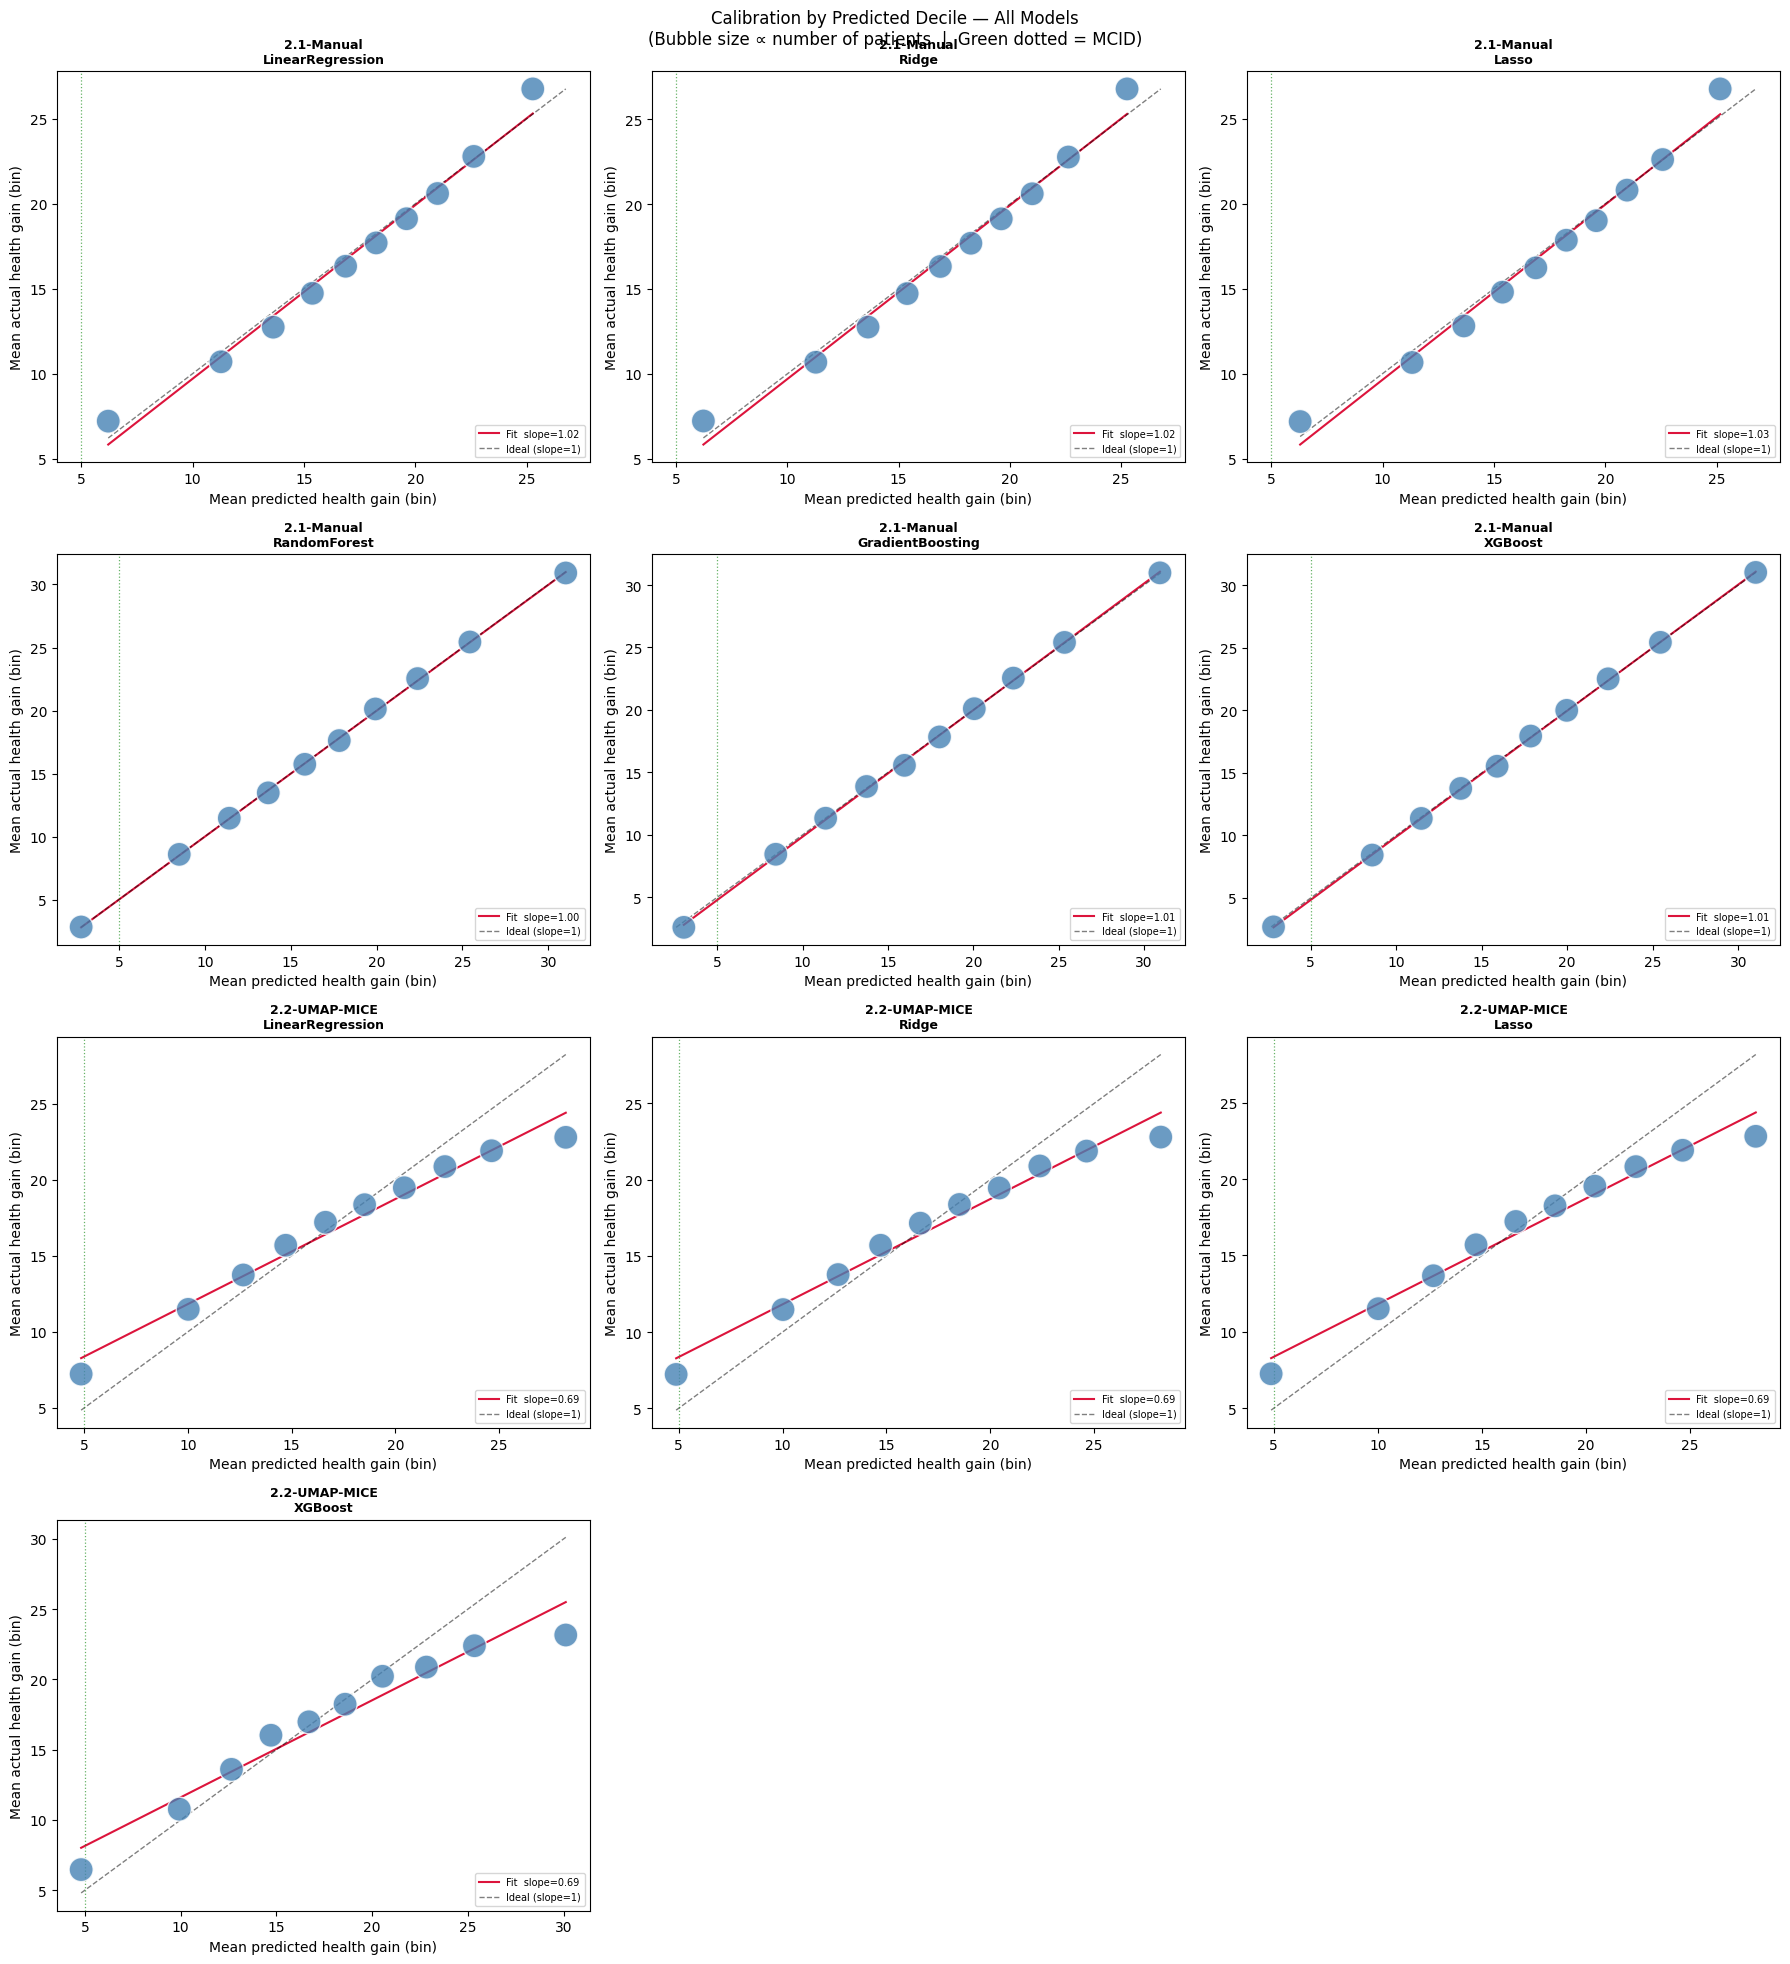


=== Calibration Slope Summary (ideal = 1.0) ===



,Dataset,Model,Calibration Slope,Interpretation
0,2.1-Manual,Lasso,1.0307,✓ Well calibrated
1,2.1-Manual,Ridge,1.0226,✓ Well calibrated
2,2.1-Manual,LinearRegression,1.0219,✓ Well calibrated
3,2.1-Manual,GradientBoosting,1.0139,✓ Well calibrated
4,2.1-Manual,XGBoost,1.0083,✓ Well calibrated
5,2.1-Manual,RandomForest,0.9992,✓ Well calibrated
6,2.2-UMAP-MICE,Ridge,0.6909,⚠ Over-shrunk
7,2.2-UMAP-MICE,XGBoost,0.6909,⚠ Over-shrunk
8,2.2-UMAP-MICE,Lasso,0.6908,⚠ Over-shrunk
9,2.2-UMAP-MICE,LinearRegression,0.6900,⚠ Over-shrunk



Slope interpretation:
  0.9–1.1 = well calibrated
  < 0.9   = regression-to-the-mean (over-shrunk) — common in tree models
  > 1.1   = over-confident extrapolation


In [ ]:
def calibration_by_decile(y_true, y_pred, n_bins=10):
    """
    Bin predictions into n_bins quantile groups,
    return mean predicted vs mean actual per bin.
    """
    # Use numpy quantile boundaries for binning
    quantile_bounds = np.percentile(y_pred, np.linspace(0, 100, n_bins + 1))
    bins = np.digitize(y_pred, quantile_bounds[1:-1])   # 0…n_bins-1

    df_cal = pl.DataFrame({'y_true': y_true, 'y_pred': y_pred, 'bin': bins})
    grouped = (
        df_cal.group_by('bin').agg([
            pl.col('y_pred').mean().alias('mean_pred'),
            pl.col('y_true').mean().alias('mean_actual'),
            pl.len().alias('n'),
        ])
        .sort('bin')
    )
    if grouped.shape[0] >= 2:
        slope, intercept, r, p, se = stats.linregress(
            grouped['mean_pred'].to_numpy(), grouped['mean_actual'].to_numpy()
        )
    else:
        slope, intercept, r = np.nan, np.nan, np.nan
    return grouped, slope, intercept


def plot_calibration(ax, grouped, slope, intercept, title):
    mean_pred_np   = grouped['mean_pred'].to_numpy()
    mean_actual_np = grouped['mean_actual'].to_numpy()
    n_np           = grouped['n'].to_numpy()

    ax.scatter(mean_pred_np, mean_actual_np,
               s=n_np / n_np.max() * 300,
               color='steelblue', alpha=0.8, edgecolors='white', zorder=3)
    x_range = np.linspace(mean_pred_np.min(), mean_pred_np.max(), 100)
    ax.plot(x_range, slope * x_range + intercept,
            color='crimson', linewidth=1.5, label=f'Fit  slope={slope:.2f}')
    lims = [min(mean_pred_np.min(), mean_actual_np.min()),
            max(mean_pred_np.max(), mean_actual_np.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.0, alpha=0.5, label='Ideal (slope=1)')
    ax.axvline(MCID, color='green', linestyle=':', linewidth=0.9, alpha=0.6)
    ax.set_xlabel('Mean predicted health gain (bin)')
    ax.set_ylabel('Mean actual health gain (bin)')
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.legend(fontsize=7)


# ── Plot calibration for all models ──────────────────────────────────────────
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes_flat = axes.flatten() if n > 1 else [axes]
fig.suptitle('Calibration by Predicted Decile — All Models\n'
             '(Bubble size ∝ number of patients  |  Green dotted = MCID)', fontsize=12)

cal_summary = []
for i, (ds, mdl, res) in enumerate(all_runs):
    grouped, slope, intercept = calibration_by_decile(res['y_test'], res['y_pred'])
    plot_calibration(axes_flat[i], grouped, slope, intercept, f'{ds}\n{mdl}')
    cal_summary.append({
        'Dataset': ds,
        'Model':   mdl,
        'Calibration Slope': round(slope, 4) if not np.isnan(slope) else float('nan'),
        'Interpretation': (
            '✓ Well calibrated'   if not np.isnan(slope) and 0.9 <= slope <= 1.1 else
            '⚠ Over-shrunk'       if not np.isnan(slope) and slope < 0.9 else
            '⚠ Over-extrapolates' if not np.isnan(slope) and slope > 1.1 else '?'
        ),
    })

for j in range(i + 1, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.show()

cal_df = pl.DataFrame(cal_summary).sort('Calibration Slope', descending=True)
print('\n=== Calibration Slope Summary ===\n')
print(cal_df)
print('\nSlope interpretation:')
print('  0.9–1.1 = well calibrated')
print('  < 0.9   = regression-to-the-mean (over-shrunk) — common in tree models')
print('  > 1.1   = over-confident extrapolation')

---
## 4. Equity & Subgroup Analysis

A model that performs well globally can **systematically fail for specific patient groups**.  
This is not just a modelling concern — it is an **NHS equality obligation**.

**What we check:**
- RMSE, MAE, and MCID-recall stratified by detected demographic columns (age, sex, deprivation)
- If no demographic columns are found in X_test, we fall back to stratifying by *pre/post-op score quintile*

**Why recall matters more than RMSE in subgroup analysis:**  
If the model has high recall for affluent patients but low recall for deprived ones, it will disproportionately deny surgery benefit to already-disadvantaged populations.

> Columns searched: any column matching `age`, `sex`, `gender`, `deprivation`, `imd`, `ethnicity`, `region`.

Equity columns to analyse: ['Age Band', 'Gender']

=== Equity Analysis: Age Band ===


,Group,N,RMSE,MAE,Recall,F2
0,1,46,9.2653,6.3788,0.9487,0.9391
1,2,2522,5.7458,4.3336,0.9773,0.9648
2,3,8492,5.4072,4.0087,0.9789,0.9687
3,4,9840,5.4696,4.0821,0.9772,0.9684
4,5,2735,5.8686,4.3949,0.9737,0.9646


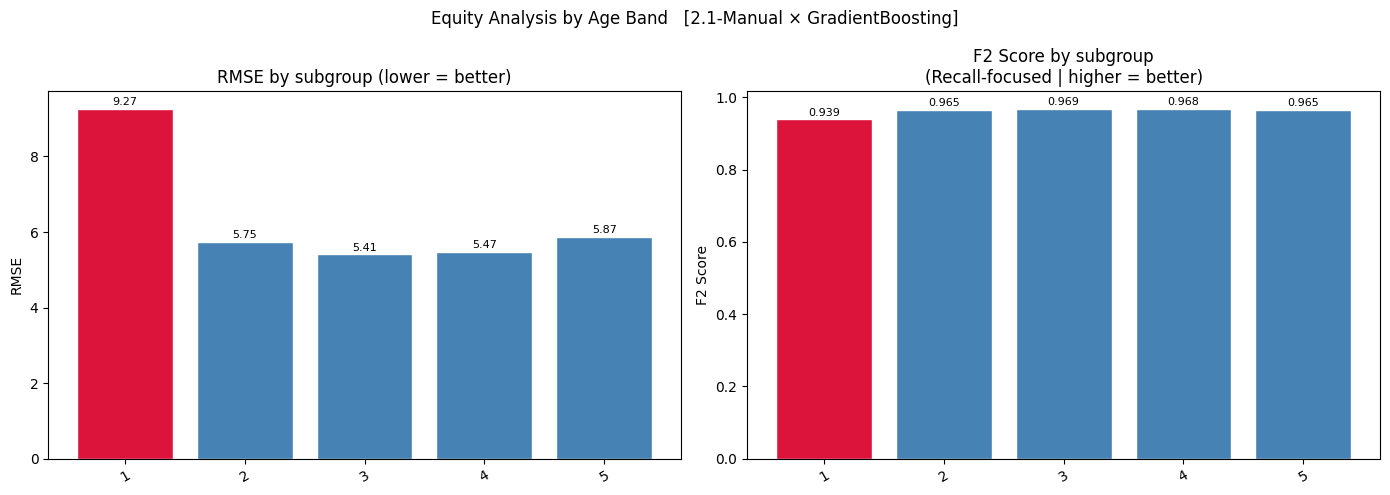


  Equity gaps for "Age Band":
    RMSE gap  : 3.8581  (max − min across groups)
    F2 gap    : 0.0296  — worst group: "1"

=== Equity Analysis: Gender ===


,Group,N,RMSE,MAE,Recall,F2
0,1.0,10131,5.2523,3.8825,0.9721,0.9635
1,2.0,13507,5.7376,4.3036,0.9812,0.9707


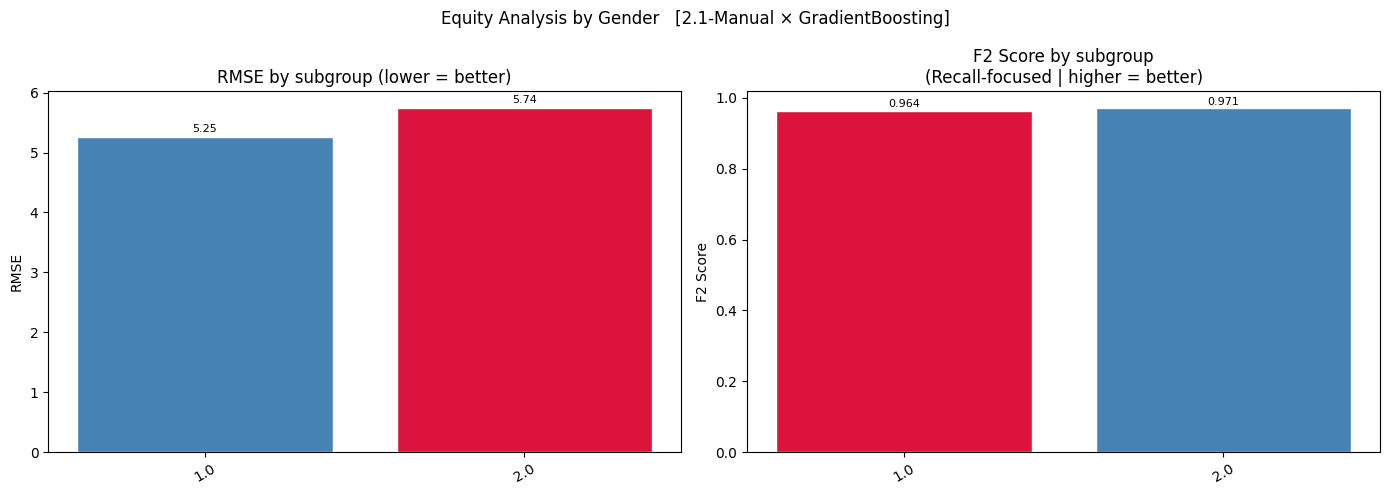


  Equity gaps for "Gender":
    RMSE gap  : 0.4853  (max − min across groups)
    F2 gap    : 0.0072  — worst group: "1.0"


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ── Identify available demographic / grouping columns ─────────────────────────
_DEMOGRAPHIC_KEYWORDS = ['age', 'sex', 'gender', 'deprivation', 'imd', 'ethnicity', 'region']

equity_cols = [
    c for c in X_test.columns
    if any(kw in c.lower() for kw in _DEMOGRAPHIC_KEYWORDS)
]

if not equity_cols:
    print('No demographic columns detected — falling back to pre-op score quintile grouping.')
    _fallback_col = numeric_cols[0] if numeric_cols else None
    if _fallback_col:
        # Quintile binning using numpy percentiles (no pandas dependency)
        quantile_bounds = np.percentile(X_test[_fallback_col].to_numpy(), [0, 20, 40, 60, 80, 100])
        bin_labels = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5']
        bins_arr   = np.digitize(X_test[_fallback_col].to_numpy(), quantile_bounds[1:-1])
        bins_arr   = np.clip(bins_arr, 0, len(bin_labels) - 1)
        X_test = X_test.with_columns(
            pl.Series('_quintile_group', [bin_labels[b] for b in bins_arr])
        )
        equity_cols = ['_quintile_group']
        print(f'Using quintile of "{_fallback_col}" as proxy group.')
    else:
        equity_cols = []
        print('No grouping possible — skipping equity analysis.')

print(f'Equity columns to analyse: {equity_cols}')


def subgroup_metrics(X_pl, y_true, y_pred, col, threshold=MCID):
    """Compute RMSE, MAE, Recall, F2 per category of `col` using Polars groupby."""
    df_eq = X_pl.select([col]).with_columns([
        pl.Series('y_true', y_true),
        pl.Series('y_pred', y_pred),
    ])
    rows = []
    for group_val in df_eq[col].unique().sort().to_list():
        sub = df_eq.filter(pl.col(col) == group_val)
        if sub.shape[0] < 5:
            continue
        yt = sub['y_true'].to_numpy()
        yp = sub['y_pred'].to_numpy()
        rmse  = np.sqrt(mean_squared_error(yt, yp))
        mae   = mean_absolute_error(yt, yp)
        yt_b  = (yt >= threshold).astype(int)
        yp_b  = (yp >= threshold).astype(int)
        rec   = recall_score(yt_b, yp_b, zero_division=0)
        f2    = fbeta_score(yt_b, yp_b, beta=2, zero_division=0)
        rows.append({
            'Group': str(group_val), 'N': sub.shape[0],
            'RMSE': round(rmse, 4), 'MAE': round(mae, 4),
            'Recall': round(rec, 4), 'F2': round(f2, 4),
        })
    return pl.DataFrame(rows) if rows else pl.DataFrame()


# ── Plot & print equity analysis for each detected column ─────────────────────
for col in equity_cols:
    sg_df = subgroup_metrics(X_test, y_test, y_pred, col)
    if sg_df.is_empty():
        print(f'No groups with ≥5 patients for "{col}" — skipping.')
        continue

    print(f'\n=== Equity Analysis: {col} ===')
    print(sg_df)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Equity Analysis by {col}   [{best_dataset} × {best_name}]', fontsize=12)

    groups    = sg_df['Group'].to_list()
    rmse_vals = sg_df['RMSE'].to_list()
    f2_vals   = sg_df['F2'].to_list()

    max_rmse = max(rmse_vals)
    min_f2   = min(f2_vals)
    colors_rmse = ['crimson' if v == max_rmse else 'steelblue' for v in rmse_vals]
    colors_f2   = ['crimson' if v == min_f2   else 'steelblue' for v in f2_vals]

    axes[0].bar(groups, rmse_vals, color=colors_rmse, edgecolor='white')
    axes[0].set_title('RMSE by subgroup (lower = better)')
    axes[0].set_ylabel('RMSE')
    axes[0].tick_params(axis='x', rotation=30)
    for bar, v in zip(axes[0].patches, rmse_vals):
        axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                     f'{v:.2f}', ha='center', va='bottom', fontsize=8)

    axes[1].bar(groups, f2_vals, color=colors_f2, edgecolor='white')
    axes[1].set_title('F2 Score by subgroup\n(Recall-focused | higher = better)')
    axes[1].set_ylabel('F2 Score')
    axes[1].tick_params(axis='x', rotation=30)
    for bar, v in zip(axes[1].patches, f2_vals):
        axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                     f'{v:.3f}', ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()

    if sg_df.shape[0] > 1:
        rmse_gap = max(rmse_vals) - min(rmse_vals)
        f2_gap   = max(f2_vals)   - min(f2_vals)
        worst_f2 = sg_df.filter(pl.col('F2') == sg_df['F2'].min())['Group'][0]
        print(f'\n  Equity gaps for "{col}":')
        print(f'    RMSE gap  : {rmse_gap:.4f}  (max − min across groups)')
        print(f'    F2 gap    : {f2_gap:.4f}  — worst group: "{worst_f2}"')
        if f2_gap > 0.1:
            print(f'    ⚠ WARNING: F2 gap > 0.10 — significant equity concern')

---
## 5. Bootstrap Prediction Intervals

Your pipeline currently produces **point predictions** — a single number per patient.  
Clinicians need to know *how confident the model is* for each individual.

**Method — Paired Bootstrap:**
1. Resample the training set with replacement `B` times
2. Refit the winning pipeline on each bootstrap sample
3. Predict on the test set with each bootstrap model → produces a distribution per patient
4. 10th / 90th percentile of that distribution = the 80% prediction interval

**What to look for:**
- **Coverage**: Does the 80% interval contain the true value ~80% of the time?
- **Width**: Wide intervals at the tails signal high individual uncertainty
- **Comparison to MCID**: If the interval width > 2 × MCID, the model cannot reliably classify patients

> `B = 100` bootstrap samples — sufficient for stable percentile estimates.  
> Uses the **winning pipeline** (dataset + model). Preprocessing is refitted inside each bootstrap to avoid data leakage.

In [ ]:
import copy
from sklearn.utils import resample
from sklearn.pipeline import clone

B                  = 100
PI_LOWER_PCT       = 10
PI_UPPER_PCT       = 90
NOMINAL_COVERAGE   = 0.80

rng = np.random.default_rng(42)

# ── Convert winner's polars data to pandas once (sklearn boundary) ────────────
X_train_pd = X_train.to_pandas()
X_test_pd  = X_test.to_pandas()

print(f'Running {B} bootstrap iterations for {best_dataset} × {best_name}...')
print('(This may take 1–2 minutes depending on the model type)')

boot_preds = np.zeros((B, len(y_test)))

for b in range(B):
    seed = int(rng.integers(0, 10_000))
    X_b, y_b = resample(X_train_pd, y_train, replace=True, random_state=seed)
    pipe_b   = clone(best_pipeline)
    pipe_b.fit(X_b, y_b)
    boot_preds[b] = pipe_b.predict(X_test_pd)

pi_lower = np.percentile(boot_preds, PI_LOWER_PCT, axis=0)
pi_upper = np.percentile(boot_preds, PI_UPPER_PCT, axis=0)
pi_width = pi_upper - pi_lower

covered  = ((y_test >= pi_lower) & (y_test <= pi_upper)).mean()

print(f'\nBootstrap complete.')
print(f'  Nominal coverage  : {NOMINAL_COVERAGE:.0%}  ({PI_LOWER_PCT}–{PI_UPPER_PCT} percentile)')
print(f'  Empirical coverage: {covered:.2%}  (ideally ≈ {NOMINAL_COVERAGE:.0%})')
print(f'  Median PI width   : {np.median(pi_width):.4f} pts')
print(f'  Mean PI width     : {np.mean(pi_width):.4f} pts')
print(f'  Max  PI width     : {np.max(pi_width):.4f} pts  (least certain patient)')
print(f'\n  MCID = {MCID} pts — PI > {2*MCID} pts means the model cannot')
print(f'  reliably classify that patient above/below the benefit threshold.')
print(f'  Patients with PI width > {2*MCID}: {(pi_width > 2*MCID).sum()} / {len(pi_width)}')

Running 100 bootstrap iterations for 2.1-Manual × GradientBoosting...
(This may take 1–2 minutes depending on the model type)


KeyboardInterrupt: 

In [ ]:
# ── Sort test patients by point prediction for a clear fan plot ───────────────
sort_idx       = np.argsort(y_pred)
y_pred_sorted  = y_pred[sort_idx]
y_test_sorted  = y_test[sort_idx]
pi_lo_sorted   = pi_lower[sort_idx]
pi_hi_sorted   = pi_upper[sort_idx]
pi_wid_sorted  = pi_width[sort_idx]
patient_idx    = np.arange(len(y_pred))

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'Bootstrap Prediction Intervals ({B} resamples) — {best_dataset} × {best_name}\n'
             f'80% PI coverage: nominal={NOMINAL_COVERAGE:.0%}  |  empirical={covered:.2%}',
             fontsize=12)

ax = axes[0]
ax.fill_between(patient_idx, pi_lo_sorted, pi_hi_sorted,
                alpha=0.25, color='steelblue', label='80% PI')
ax.scatter(patient_idx, y_test_sorted,  color='black',   s=6,  alpha=0.5, label='Actual',    zorder=5)
ax.scatter(patient_idx, y_pred_sorted,  color='crimson', s=6,  alpha=0.6, label='Predicted', zorder=4)
ax.axhline(MCID, color='green', linestyle='--', linewidth=1.2, label=f'MCID={MCID}')
ax.set_xlabel('Patients (sorted by predicted gain)')
ax.set_ylabel('Health gain (OKS)')
ax.set_title('Prediction intervals — sorted patients')
ax.legend(fontsize=8)

ax2 = axes[1]
ax2.hist(pi_width, bins=30, edgecolor='white', alpha=0.7, color='steelblue')
ax2.axvline(np.median(pi_width), color='crimson',  linestyle='-',  linewidth=1.5,
            label=f'Median={np.median(pi_width):.2f}')
ax2.axvline(2 * MCID, color='orange', linestyle='--', linewidth=1.5,
            label=f'2×MCID={2*MCID} (unclassifiable zone)')
ax2.set_xlabel('PI width (pts)')
ax2.set_ylabel('Count')
ax2.set_title('Distribution of interval widths')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Build PI summary table using Polars ───────────────────────────────────────
df_pi = pl.DataFrame({
    'Actual':      y_test.tolist(),
    'Predicted':   y_pred.tolist(),
    'PI lower':    pi_lower.tolist(),
    'PI upper':    pi_upper.tolist(),
    'PI width':    pi_width.tolist(),
    'Crosses MCID threshold': [int((lo < MCID) and (hi >= MCID))
                               for lo, hi in zip(pi_lower, pi_upper)],
})

print('\n=== 10 Most uncertain patients (widest PI) ===')
print(df_pi.sort('PI width', descending=True).head(10))

print('\n=== 10 Most confident patients (narrowest PI) ===')
print(df_pi.sort('PI width').head(10))

n_ambiguous = df_pi['Crosses MCID threshold'].sum()
print(f'\n  Patients whose PI straddles the MCID threshold: {n_ambiguous} / {df_pi.shape[0]}')
print(f'  These patients cannot be reliably classified by this model.')

NameError: name 'pi_upper' is not defined

---
## 6. Summary Dashboard

Combined scorecard across **all five evaluation dimensions** for every (dataset × model) pair.

| Metric | Ideal direction | What it reveals |
|---|---|---|
| Test RMSE | ↓ | Average prediction error |
| Bias (B-A) | → 0 | Systematic over/under-prediction |
| LoA Width | ↓ | Individual prediction precision |
| F2 Score | ↑ | Clinical classification (recall-weighted) |
| Calib. Slope | → 1 | Tail calibration quality |

=== [4.1] Clinical Evaluation Scorecard — All Models ===



,Dataset,Model,Test RMSE,Test R²,Bias,LoA Width,LoA≤MCID?,Recall,F2,FN count,Calib. Slope,Calib. Quality
0,2.1-Manual,GradientBoosting,5.534800,0.681700,0.054400,21.695300,✗ No,0.977300,0.967600,476,1.013900,✓ Well calibrated
1,2.1-Manual,XGBoost,5.534900,0.681700,0.059700,21.695700,✗ No,0.977000,0.967300,484,1.008300,✓ Well calibrated
2,2.1-Manual,RandomForest,5.645900,0.668800,0.015600,22.131800,✗ No,0.974800,0.965400,529,0.999200,✓ Well calibrated
3,2.1-Manual,Ridge,8.124500,0.314100,0.145200,31.842800,✗ No,0.983000,0.964500,358,1.022600,✓ Well calibrated
4,2.1-Manual,Lasso,8.127100,0.313700,0.142000,31.853200,✗ No,0.983400,0.964900,348,1.030700,✓ Well calibrated
5,2.1-Manual,LinearRegression,8.127100,0.313600,0.146400,31.853200,✗ No,0.982800,0.964400,361,1.021900,✓ Well calibrated
6,2.2-UMAP-MICE,XGBoost,8.798700,0.195500,0.749700,34.365501,✗ No,0.973900,0.959400,548,0.690900,⚠ Over-shrunk
7,2.2-UMAP-MICE,Lasso,8.879800,0.180600,0.438300,34.766300,✗ No,0.971700,0.957000,594,0.690800,⚠ Over-shrunk
8,2.2-UMAP-MICE,Ridge,8.881500,0.180300,0.441900,34.772500,✗ No,0.971800,0.957000,593,0.690900,⚠ Over-shrunk
9,2.2-UMAP-MICE,LinearRegression,8.885400,0.179600,0.443600,34.787200,✗ No,0.971900,0.957100,591,0.690000,⚠ Over-shrunk


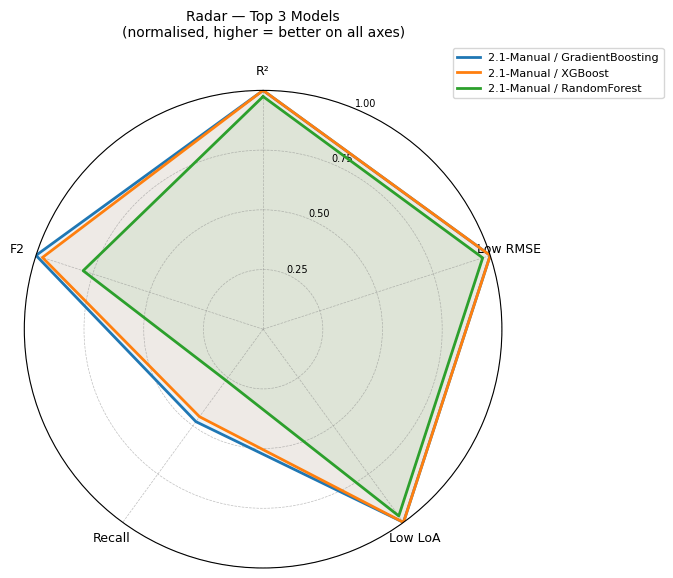


  CLINICAL EVALUATION VERDICT
  Best overall model : GradientBoosting  on  2.1-Manual
  Test RMSE          : 5.5348  |  R² : 0.6817
  Bland-Altman bias  : 0.0544  pts  (ideal = 0)
  LoA width          : 21.6953  pts  ✗ exceeds MCID — individual predictions uncertain
  MCID Recall        : 0.9773  |  F2 : 0.9676
  Calibration slope  : 1.0139  (✓ Well calibrated)


NameError: name 'covered' is not defined

In [ ]:
# ── Merge all partial results into one scorecard (Polars) ─────────────────────
ba_lookup  = {(r['Dataset'], r['Model']): r for r in ba_summary}
cm_lookup  = {(r['Dataset'], r['Model']): r for r in cm_summary}
cal_lookup = {(r['Dataset'], r['Model']): r for r in cal_summary}

scorecard_rows = []
for ds, mdl, res in all_runs:
    key  = (ds, mdl)
    ba   = ba_lookup.get(key, {})
    cm   = cm_lookup.get(key, {})
    cal  = cal_lookup.get(key, {})
    scorecard_rows.append({
        'Dataset':        ds,
        'Model':          mdl,
        'Test RMSE':      round(res['test_rmse'], 4),
        'Test R²':        round(res['test_r2'],   4),
        'Bias':           ba.get('Bias', float('nan')),
        'LoA Width':      ba.get('LoA Width', float('nan')),
        'LoA≤MCID?':      ba.get('LoA Within MCID?', '?'),
        'Recall':         cm.get('Recall (Sensitivity)', float('nan')),
        'F2':             cm.get('F2 (β=2)', float('nan')),
        'FN count':       cm.get('FN', float('nan')),
        'Calib. Slope':   cal.get('Calibration Slope', float('nan')),
        'Calib. Quality': cal.get('Interpretation', '?'),
    })

scorecard_df = pl.DataFrame(scorecard_rows).sort('Test RMSE')

print('=== [4.1] Clinical Evaluation Scorecard — All Models ===\n')
print(scorecard_df)


# ── Radar chart for the top-3 models ─────────────────────────────────────────
def normalise_col_arr(values, higher_is_better=True):
    arr = np.array(values, dtype=float)
    mn, mx = np.nanmin(arr), np.nanmax(arr)
    if mn == mx:
        return np.full_like(arr, 0.5)
    normed = (arr - mn) / (mx - mn)
    return normed if higher_is_better else 1 - normed


metrics_radar = {
    'R²':       ('Test R²',    True),
    'Low RMSE': ('Test RMSE',  False),
    'Low LoA':  ('LoA Width',  False),
    'Recall':   ('Recall',     True),
    'F2':       ('F2',         True),
}

top3 = scorecard_df.head(3)
radar_vals = {}
for label, (col, hib) in metrics_radar.items():
    all_vals = scorecard_df[col].to_numpy().astype(float)
    normed   = normalise_col_arr(all_vals, hib)
    radar_vals[label] = normed[:3]

categories = list(metrics_radar.keys())
N          = len(categories)
angles     = [n / float(N) * 2 * np.pi for n in range(N)]
angles    += angles[:1]

fig_r, ax_r = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
ax_r.set_theta_offset(np.pi / 2)
ax_r.set_theta_direction(-1)
ax_r.set_thetagrids(np.degrees(angles[:-1]), categories, fontsize=9)
ax_r.set_ylim(0, 1)
ax_r.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_r.set_yticklabels(['0.25', '0.50', '0.75', '1.00'], fontsize=7)
ax_r.grid(color='grey', linestyle='--', linewidth=0.5, alpha=0.5)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for idx in range(min(3, top3.shape[0])):
    row    = top3.row(idx, named=True)
    values = [radar_vals[cat][idx] for cat in categories] + [radar_vals[categories[0]][idx]]
    label  = f'{row["Dataset"]} / {row["Model"]}'
    ax_r.plot(angles, values, linewidth=2, color=colors[idx], label=label)
    ax_r.fill(angles, values, alpha=0.08, color=colors[idx])

ax_r.set_title('Radar — Top 3 Models\n(normalised, higher = better on all axes)',
               fontsize=10, pad=20)
ax_r.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=8)
plt.tight_layout()
plt.show()


# ── Plain-English Verdict ─────────────────────────────────────────────────────
winner = scorecard_df.row(0, named=True)
print('\n' + '=' * 60)
print('  CLINICAL EVALUATION VERDICT')
print('=' * 60)
print(f"  Best overall model : {winner['Model']}  on  {winner['Dataset']}")
print(f"  Test RMSE          : {winner['Test RMSE']}  |  R² : {winner['Test R²']}")
print(f"  Bland-Altman bias  : {winner['Bias']}  pts  (ideal = 0)")
print(f"  LoA width          : {winner['LoA Width']}  pts  {'✓ within MCID' if winner['LoA≤MCID?'] == '✓ Yes' else '✗ exceeds MCID — individual predictions uncertain'}")
print(f"  MCID Recall        : {winner['Recall']}  |  F2 : {winner['F2']}")
print(f"  Calibration slope  : {winner['Calib. Slope']}  ({winner['Calib. Quality']})")
print('=' * 60)
print(f"\n  Bootstrap coverage  : {covered:.2%}  (nominal {NOMINAL_COVERAGE:.0%})")
print(f"  Median PI width    : {np.median(pi_width):.2f} pts")
print(f"  Patients ambiguous at MCID: {n_ambiguous} / {len(y_test)}")
print('=' * 60)